In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost 
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:

df = pd.read_csv('Copia de data_merged.csv')



In [3]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [4]:
df

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,electro_focus_yr,vocal_energy_yr,energy_ratio_,electro_focus,vocal_energy,energy_ratio_ar,electro_focus_ar,vocal_energy_ar,temp_moderado,temp_rapido
0,0.013100,0.2560,3.039117,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.037649,0.495522,0.011725,0.000094,0.894905,0.105519,1.463051e-02,0.709725,0,1
1,0.980000,0.2770,3.449533,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.009108,0.183282,0.142100,0.002549,0.017545,0.208915,4.504740e-03,0.097838,1,0
2,0.795000,0.6850,5.244450,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.010180,0.186780,0.383985,0.086935,0.058926,0.491828,6.804020e-02,0.059278,1,0
3,0.656000,0.7880,2.995783,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.010180,0.186780,0.530048,0.000000,0.808000,0.537642,2.723306e-07,0.744999,1,0
4,0.302000,0.0753,8.309333,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.007777,0.179243,0.045300,0.092555,0.017400,0.253033,3.753181e-02,0.103445,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172225,0.000067,0.5670,0.616667,0.862,0,0.875000,0.4810,-5.617,0,0.0670,...,0.116161,0.507938,0.000058,0.754199,0.107750,0.000040,5.311705e-01,0.370306,0,1
172226,0.000994,0.3960,8.363733,0.979,0,0.609000,0.1360,-9.138,0,0.0878,...,0.133639,0.491948,0.000973,0.595618,0.382789,0.016665,1.873520e-01,0.759704,0,1
172227,0.864000,0.6380,2.692667,0.156,0,0.000000,0.1830,-17.372,20,0.0741,...,0.013051,0.250225,0.134784,0.000000,0.156000,0.131158,2.533831e-04,0.142178,1,0
172228,0.029900,0.5330,5.713783,0.547,0,0.011300,0.0723,-9.290,35,0.0326,...,0.031967,0.443442,0.016355,0.005996,0.540819,0.098186,1.820001e-02,0.678454,1,0


In [4]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

def categorize_popularity(popularity):
    if popularity<=20:
        return 0 # baja
    elif popularity <=45:
        return 1 # media
    return 2 # alta
    

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 73762 (42.8%)
   1 (Media): 62074 (36.0%)
   2 (Alta): 36394 (21.1%)


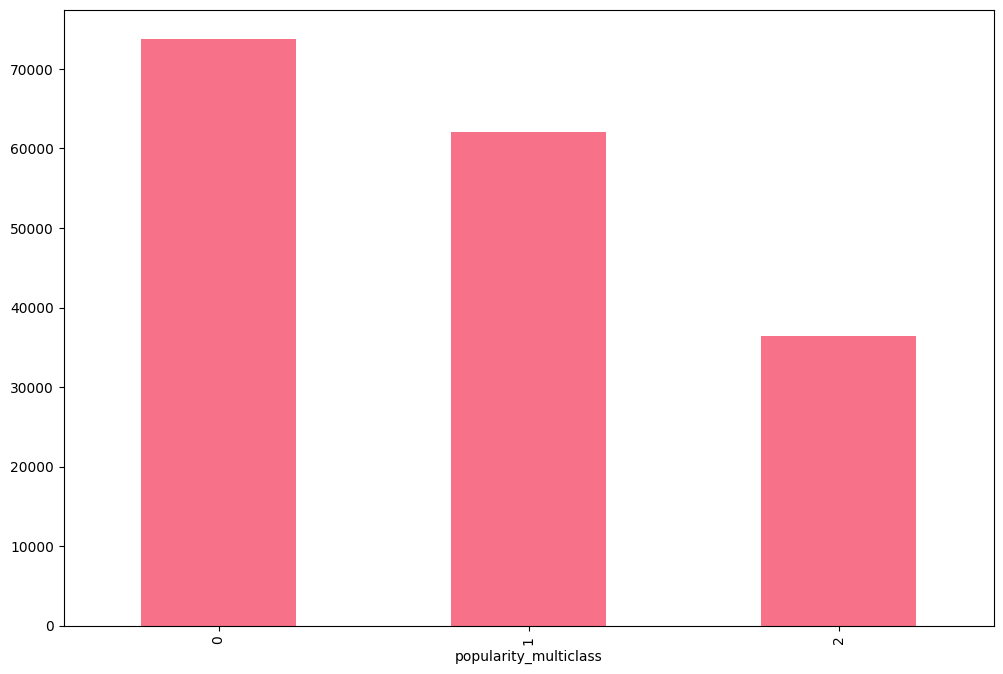

In [6]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')
plt.savefig('3clases.png',dpi=421)

In [5]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [6]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,73762.0,4.438369,6.348734,0.0,0.0,0.0,8.0,20.0
1,62074.0,32.917051,6.956338,21.0,27.0,33.0,39.0,45.0
2,36394.0,57.551904,8.900427,46.0,50.0,56.0,63.0,100.0


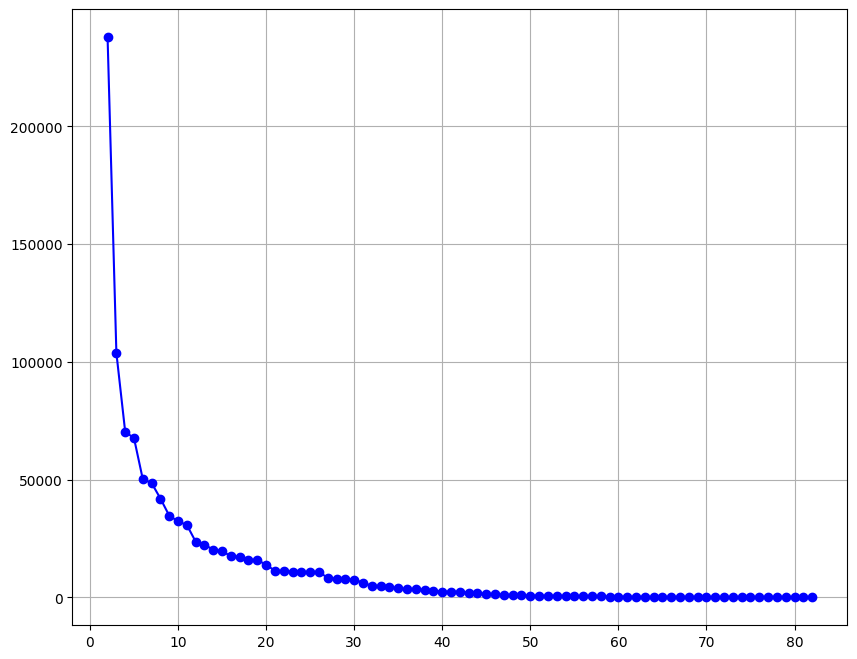

In [9]:

selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [7]:
selector = SelectKBest(score_func=f_classif,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['popularity_ar', 'acousticness_yr', 'energy_yr',
       'instrumentalness_yr', 'popularity_yr', 'vocal_energy_yr'],
      dtype=object)

In [8]:
_X=X.copy()
y =y_multiclass_3

In [9]:
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)


In [10]:
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

Fitting 5 folds for each of 4 candidates, totalling 20 fits

KNN
Best params: {'n_neighbors': 9}
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     14752
           1       0.72      0.81      0.76     12415
           2       0.79      0.58      0.67      7279

    accuracy                           0.80     34446
   macro avg       0.80      0.77      0.78     34446
weighted avg       0.81      0.80      0.80     34446



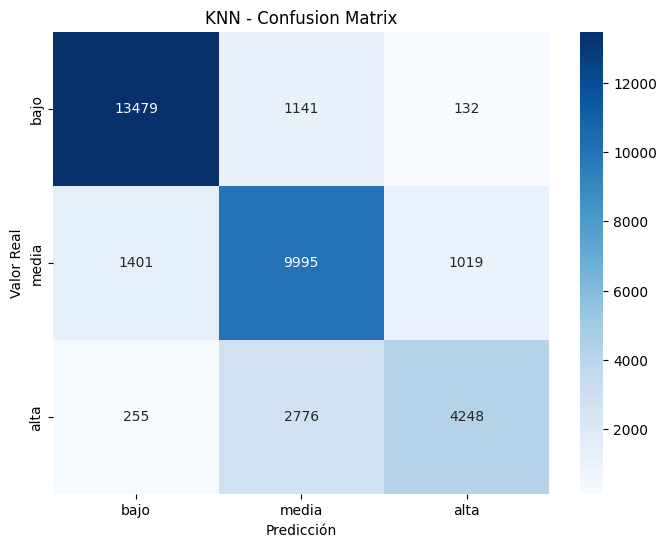

train

KNN
Best params: {'n_neighbors': 9}
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     59010
           1       0.76      0.86      0.81     49659
           2       0.85      0.63      0.72     29115

    accuracy                           0.84    137784
   macro avg       0.84      0.81      0.82    137784
weighted avg       0.84      0.84      0.84    137784



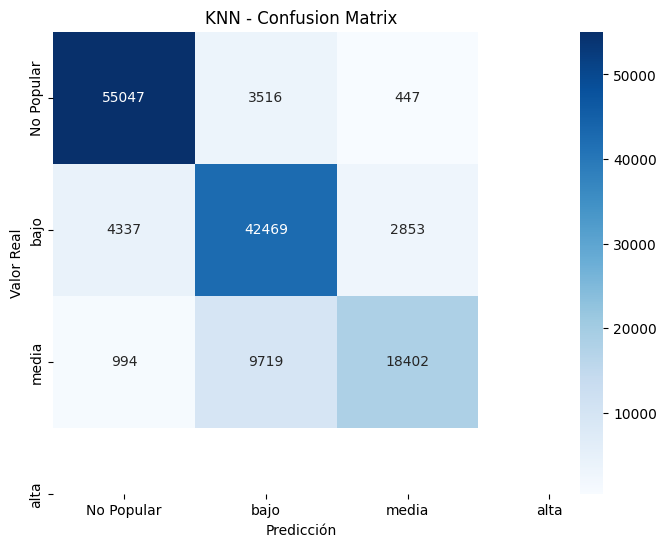

error 'KNeighborsClassifier' object has no attribute 'feature_importances_'


In [11]:
from sklearn.ensemble import ExtraTreesClassifier,HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
models = {
    'KNN': KNeighborsClassifier(),
  
}
param_grids = {
    
    'KNN': {
        'n_neighbors':[3,5,7,9]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 4 candidates, totalling 20 fits

RandomForest
Best params: {'max_depth': None, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.78      0.85      0.81     12415
           2       0.85      0.68      0.76      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.86      0.85      0.85     34446



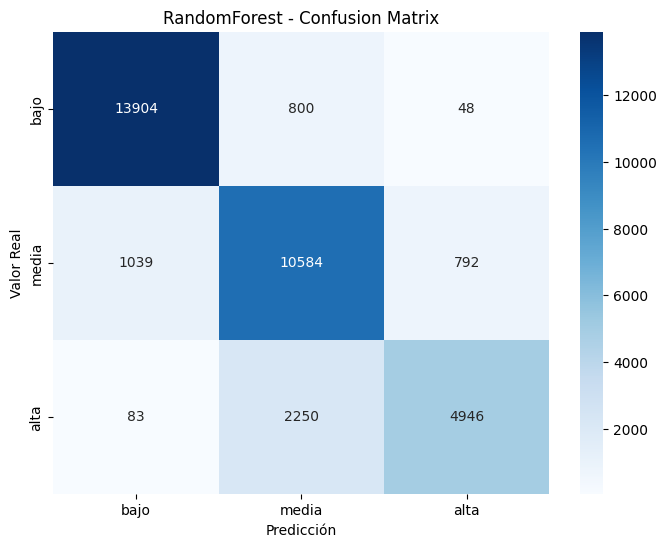

train

RandomForest
Best params: {'max_depth': None, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59010
           1       1.00      1.00      1.00     49659
           2       0.99      1.00      1.00     29115

    accuracy                           1.00    137784
   macro avg       1.00      1.00      1.00    137784
weighted avg       1.00      1.00      1.00    137784



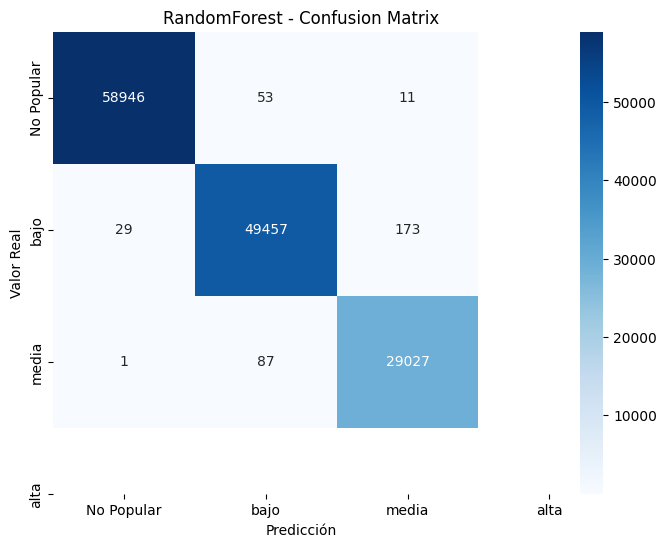

[1.71526385e-02 1.58909742e-02 1.77471689e-02 1.51053086e-02
 1.32353053e-03 1.44807246e-02 1.66166191e-02 1.72283055e-02
 1.61940885e-02 1.57613739e-02 1.54594162e-02 4.69768567e-02
 1.82019462e-03 1.27519696e-03 1.63255802e-03 8.88074221e-04
 1.42252818e-03 1.53433578e-03 9.61593373e-04 1.76456208e-03
 1.16950874e-03 1.61842109e-03 1.25206562e-03 1.05050249e-03
 1.90998303e-03 1.99104306e-03 1.70910475e-02 1.03065577e-02
 1.21077517e-02 1.26686254e-02 1.64052860e-02 1.08494236e-02
 1.37370251e-02 1.02959959e-02 9.75049098e-03 9.70556577e-03
 1.82399809e-01 1.36943807e-02 1.23186138e-03 6.87588517e-04
 1.00511317e-03 2.42396255e-04 6.79836023e-04 9.29661926e-04
 4.17438743e-04 1.24584967e-03 5.71423226e-04 1.16417004e-03
 7.05822406e-04 5.46367133e-04 8.08957432e-04 7.31808054e-04
 2.80186027e-02 1.08535074e-02 8.37842408e-03 4.04490755e-02
 2.54986780e-02 6.48274024e-03 4.01856304e-02 2.53021623e-02
 2.84732683e-02 1.57191733e-02 4.09424683e-02 0.00000000e+00
 8.26702313e-04 3.345771

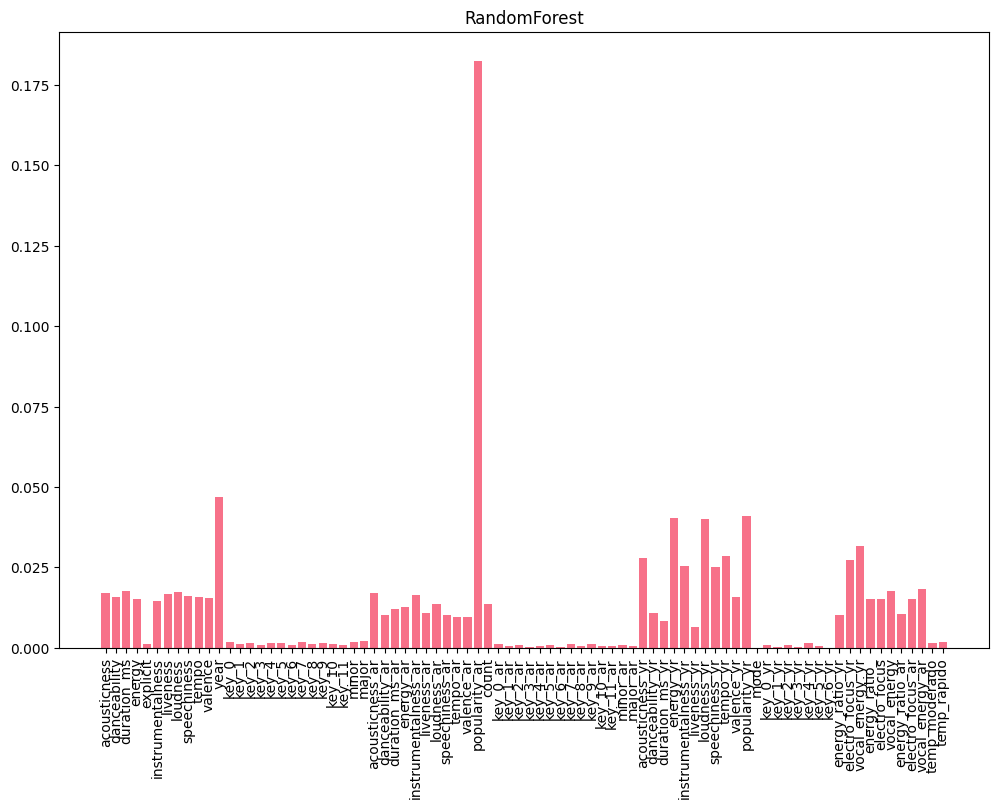

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.86      0.67      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



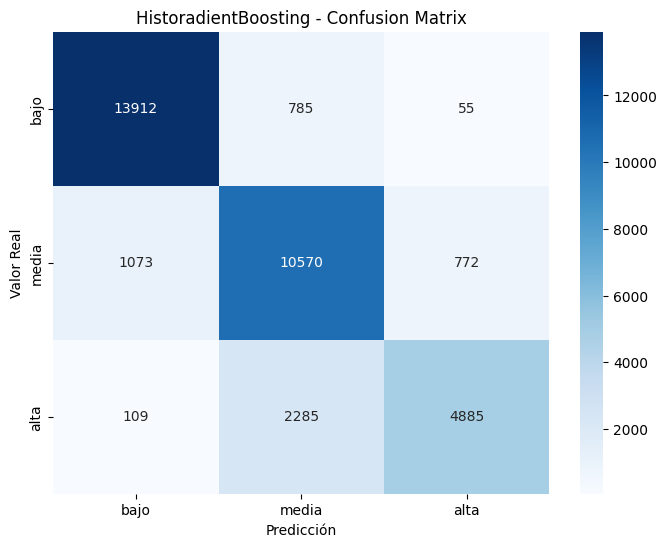

train

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     59010
           1       0.80      0.88      0.84     49659
           2       0.89      0.70      0.78     29115

    accuracy                           0.87    137784
   macro avg       0.88      0.84      0.86    137784
weighted avg       0.88      0.87      0.87    137784



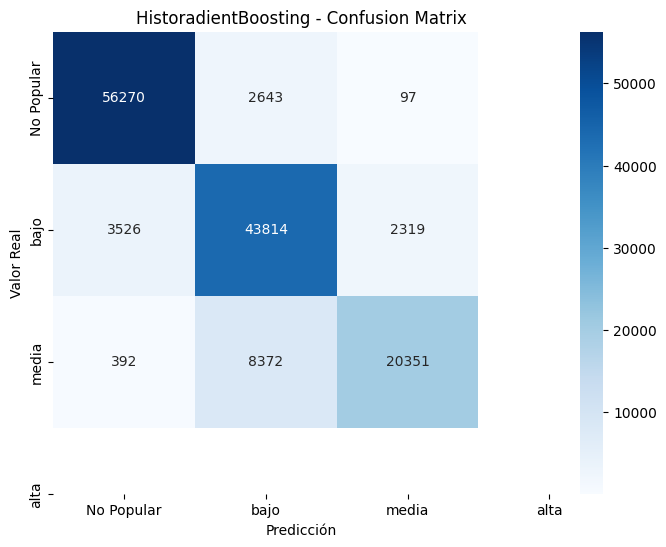

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.86      0.67      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.86      0.85      0.85     34446



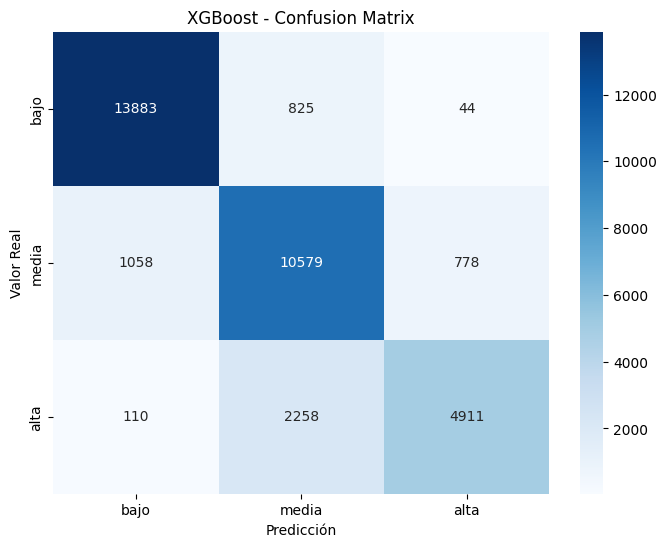

train

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.94      0.95      0.94     59010
           1       0.80      0.88      0.84     49659
           2       0.89      0.70      0.79     29115

    accuracy                           0.87    137784
   macro avg       0.88      0.85      0.86    137784
weighted avg       0.88      0.87      0.87    137784



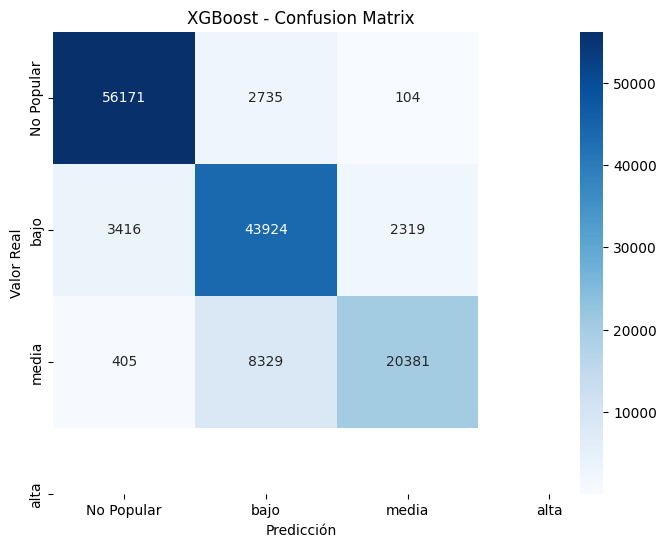

[0.00255906 0.00246863 0.00379211 0.00259985 0.00163353 0.00414621
 0.00378174 0.00291012 0.00343438 0.00235042 0.00229902 0.08244379
 0.00217052 0.001776   0.00333516 0.00107053 0.00183119 0.00207436
 0.00148863 0.00266894 0.00192823 0.00224254 0.00296518 0.00174152
 0.00233069 0.         0.0034036  0.00386304 0.00353255 0.00283893
 0.00387578 0.00293512 0.00296615 0.00306541 0.00240196 0.00281796
 0.25753364 0.00841193 0.00386245 0.00204591 0.00360711 0.0024731
 0.00295228 0.00364317 0.00208363 0.0046105  0.00326632 0.00330741
 0.00564713 0.00094127 0.00582019 0.0013664  0.01166124 0.00465241
 0.00864313 0.01022829 0.09021155 0.0041213  0.01236853 0.17577916
 0.00714207 0.02151981 0.07237256 0.         0.00326804 0.00451554
 0.0037386  0.00298586 0.00582085 0.00313399 0.00053505 0.00388182
 0.00601538 0.0434132  0.00210865 0.00286498 0.00245451 0.00279685
 0.00555968 0.00289173 0.         0.        ]


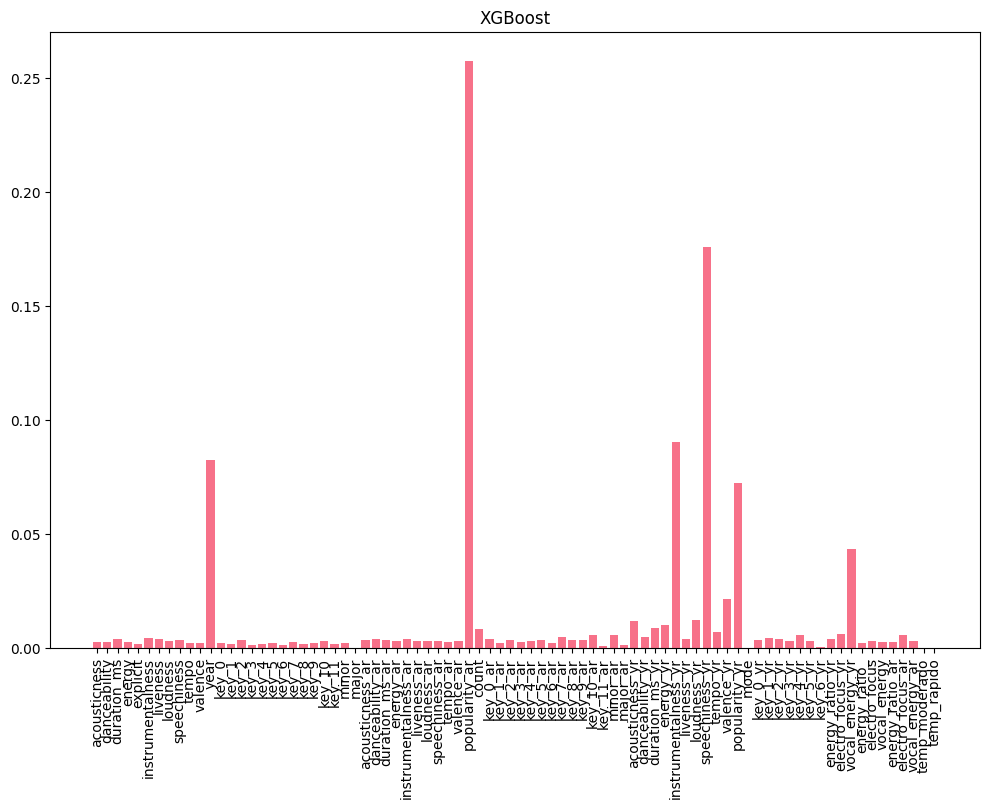

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.77      0.83      0.80     12415
           2       0.81      0.69      0.74      7279

    accuracy                           0.85     34446
   macro avg       0.84      0.82      0.82     34446
weighted avg       0.85      0.85      0.84     34446



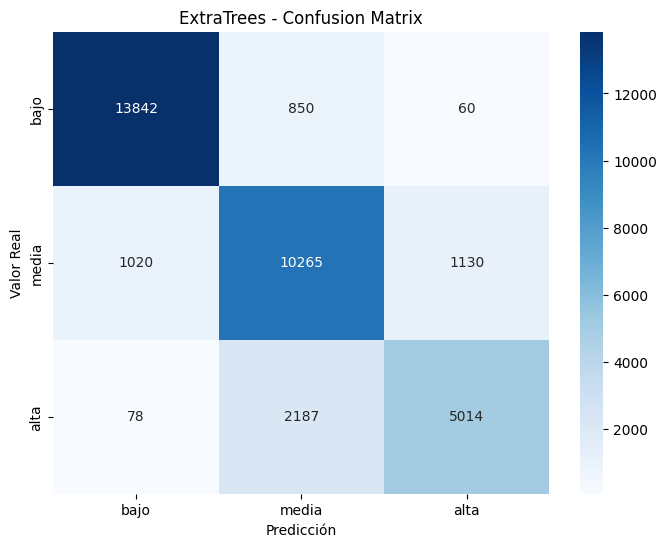

train

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     59010
           1       0.89      0.95      0.92     49659
           2       0.94      0.85      0.89     29115

    accuracy                           0.94    137784
   macro avg       0.94      0.93      0.93    137784
weighted avg       0.94      0.94      0.94    137784



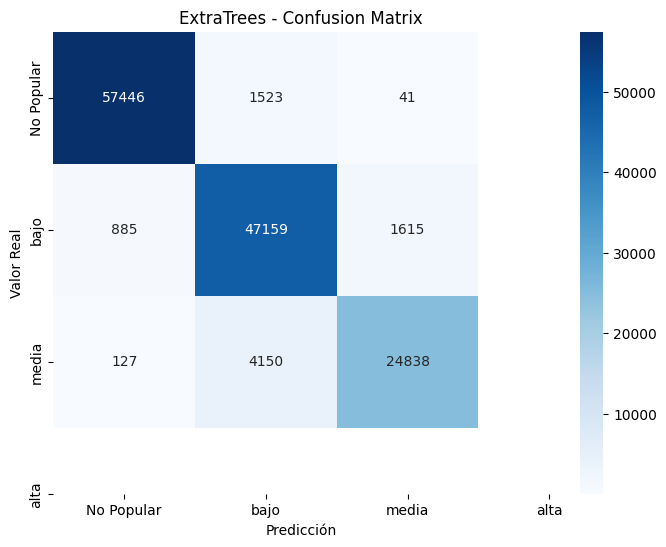

[1.36313089e-02 5.81144228e-03 5.65430570e-03 7.05749931e-03
 5.47332195e-03 1.13380233e-02 6.21692633e-03 7.49236122e-03
 6.33031072e-03 4.93016651e-03 5.39713313e-03 6.01288477e-02
 2.25515152e-03 1.83711147e-03 2.09752544e-03 1.30899713e-03
 1.85101941e-03 2.00492179e-03 1.39779164e-03 2.21998996e-03
 1.69112335e-03 2.11738502e-03 1.74630500e-03 1.53448678e-03
 2.58169862e-03 2.62945784e-03 1.82235054e-02 6.13388206e-03
 5.86360899e-03 1.01052396e-02 1.91823167e-02 6.44017512e-03
 8.34404865e-03 7.16256936e-03 4.71125927e-03 5.66268158e-03
 1.68954680e-01 1.04792764e-02 3.11496653e-03 1.92373918e-03
 2.44238916e-03 7.00173502e-04 1.91850398e-03 2.19813547e-03
 1.30532339e-03 2.88220932e-03 1.50842250e-03 3.07637490e-03
 1.76307166e-03 1.28985491e-03 2.43006451e-03 1.92524304e-03
 4.11868057e-02 1.36763094e-02 1.20679104e-02 5.94674555e-02
 3.02786077e-02 6.30974226e-03 4.76558462e-02 2.16399589e-02
 2.52748823e-02 2.09750239e-02 5.83056552e-02 0.00000000e+00
 2.09610454e-03 2.126000

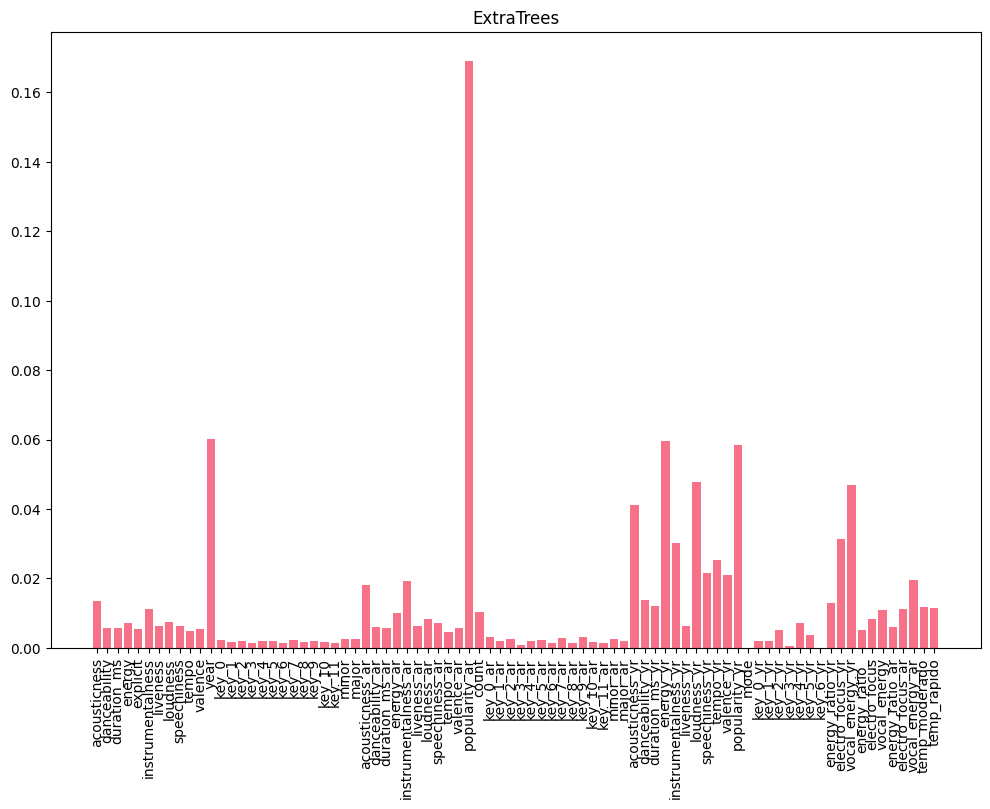

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.93      0.93     14752
           1       0.78      0.80      0.79     12415
           2       0.78      0.73      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.83      0.82      0.82     34446
weighted avg       0.84      0.84      0.84     34446



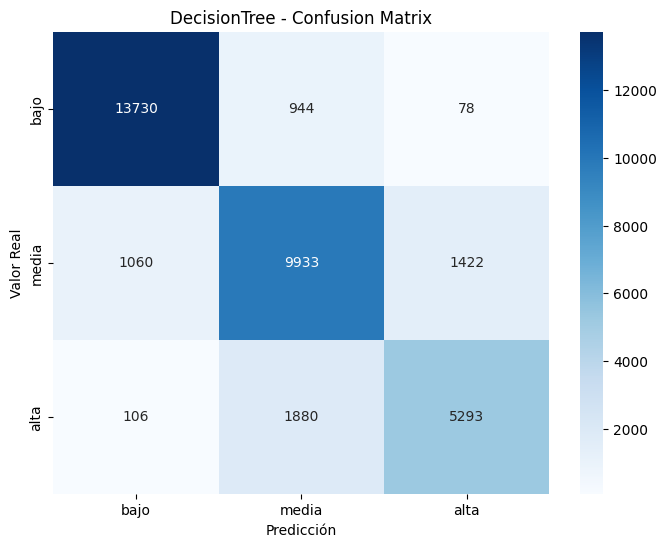

train

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     59010
           1       0.79      0.82      0.81     49659
           2       0.80      0.74      0.77     29115

    accuracy                           0.85    137784
   macro avg       0.84      0.83      0.84    137784
weighted avg       0.85      0.85      0.85    137784



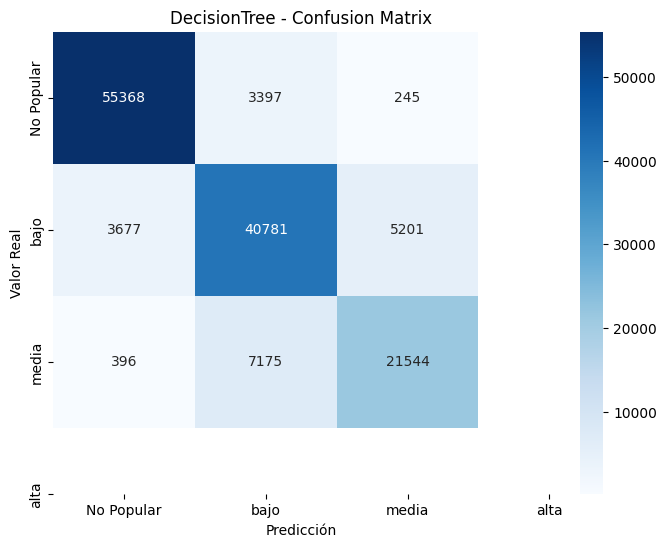

[9.96895126e-04 1.59789390e-03 3.07050475e-03 3.69113572e-04
 1.63790611e-04 1.76698054e-04 2.56926279e-03 1.50718401e-03
 1.70140090e-03 1.34959817e-03 1.76049449e-03 1.82848429e-02
 5.83238644e-05 2.54230788e-05 0.00000000e+00 2.78711526e-05
 2.75650121e-05 0.00000000e+00 1.64346868e-19 2.41083224e-05
 1.04810643e-05 2.83631321e-05 9.06833820e-06 7.57977120e-05
 0.00000000e+00 3.44616671e-05 1.18824799e-03 1.38138475e-03
 1.40613584e-03 4.91374918e-04 1.36846168e-03 1.35105614e-03
 1.45555449e-03 1.08418379e-03 6.79685371e-04 2.56319062e-03
 8.32325428e-01 1.44454750e-02 0.00000000e+00 0.00000000e+00
 4.80598954e-05 2.60293071e-05 7.02475835e-05 1.22751178e-04
 8.69514992e-05 4.30748489e-04 0.00000000e+00 2.04883394e-04
 1.32676548e-04 0.00000000e+00 0.00000000e+00 2.67244942e-05
 7.82564789e-03 1.81992511e-03 1.30072183e-03 2.81882032e-03
 1.79468973e-03 3.80995418e-04 1.78751643e-02 2.63851930e-02
 6.78101542e-04 2.60676977e-04 3.24577792e-02 0.00000000e+00
 1.34795148e-04 0.000000

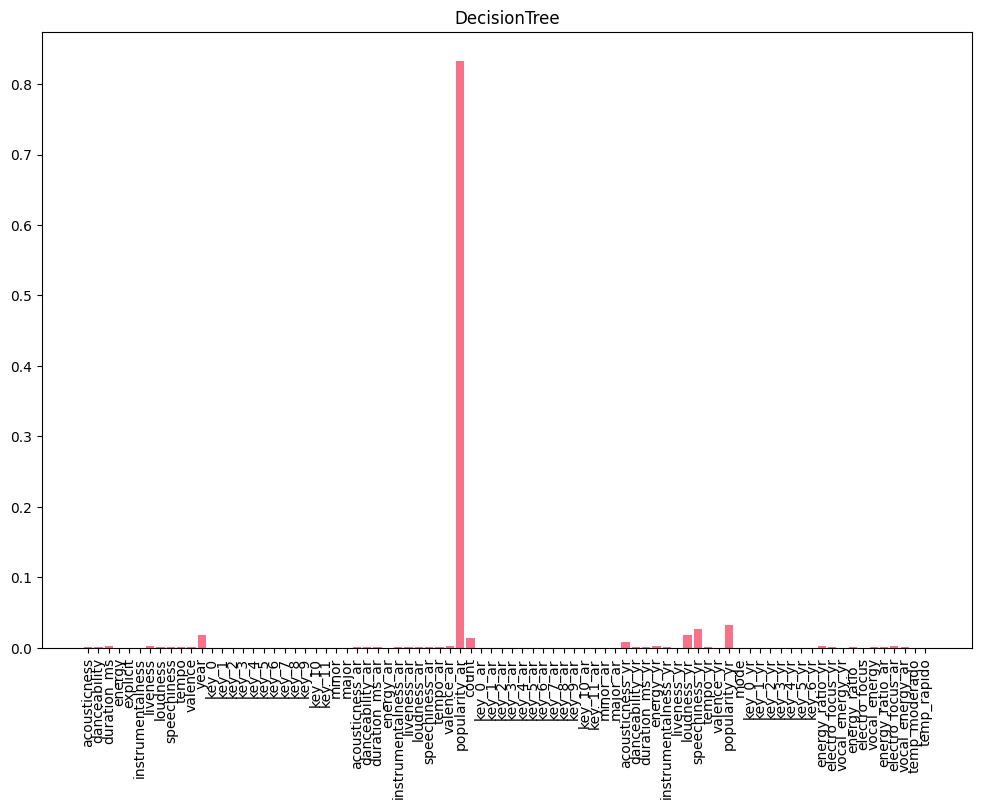

In [14]:
from sklearn.ensemble import ExtraTreesClassifier,HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 10]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

In [15]:
"""from sklearn.utils import class_weight
class_wigths = class_weight.compute_class_weight('balanced',classes=np.unique(y),y=y)

w = dict(zip(np.unique(y),class_wigths))
svc = SVC(kernel='rbf',probability=True,cache_size=1000,decision_function_shape='ovr',class_weight=w,verbose=2)
svc.fit(X_train_reduce,y_train_reduce)
y_pred = svc.predict(X_test_scaled)
r = classification_report(y_test_reduce, y_pred)

print(r)
cm = confusion_matrix(y_test_reduce, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
              yticklabels=['No Popular', 'bajo','media','alta'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()"""

"from sklearn.utils import class_weight\nclass_wigths = class_weight.compute_class_weight('balanced',classes=np.unique(y),y=y)\n\nw = dict(zip(np.unique(y),class_wigths))\nsvc = SVC(kernel='rbf',probability=True,cache_size=1000,decision_function_shape='ovr',class_weight=w,verbose=2)\nsvc.fit(X_train_reduce,y_train_reduce)\ny_pred = svc.predict(X_test_scaled)\nr = classification_report(y_test_reduce, y_pred)\n\nprint(r)\ncm = confusion_matrix(y_test_reduce, y_pred)\nplt.figure(figsize=(8,6))\nsns.heatmap(cm, annot=True, fmt='d', cmap='Blues',\n                xticklabels=['No Popular', 'bajo','media','alta'],\n              yticklabels=['No Popular', 'bajo','media','alta'])\nplt.ylabel('Valor Real')\nplt.xlabel('Predicción')\nplt.show()"

# K=30

Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.78      0.84      0.81     12415
           2       0.83      0.70      0.76      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.83      0.83     34446
weighted avg       0.85      0.85      0.85     34446



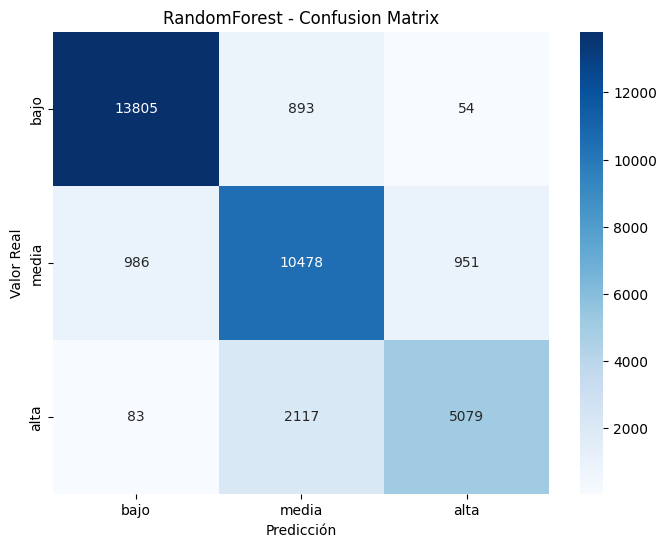

train

RandomForest
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     59010
           1       0.90      0.98      0.94     49659
           2       0.98      0.86      0.92     29115

    accuracy                           0.96    137784
   macro avg       0.96      0.94      0.95    137784
weighted avg       0.96      0.96      0.96    137784



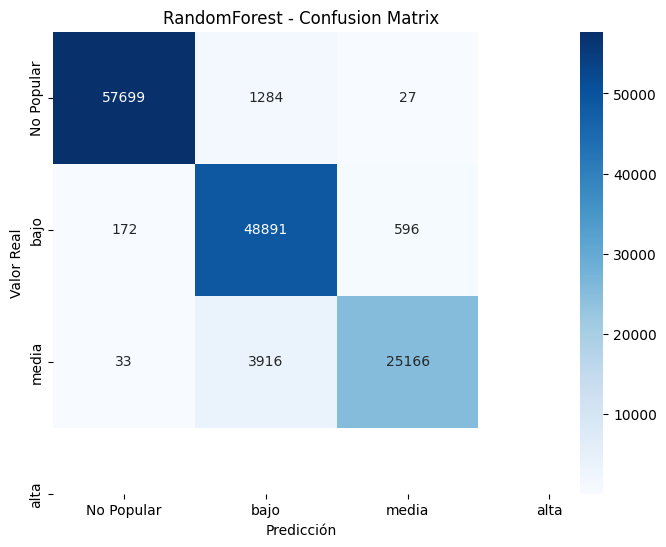

[2.91145804e-02 2.73120610e-02 2.79953253e-02 3.02473941e-02
 7.55632289e-02 2.45828280e-02 1.97227393e-02 2.76452873e-02
 2.18897788e-02 2.54499560e-01 2.40468224e-02 3.26227346e-02
 9.18063899e-03 8.28956445e-03 4.67931799e-02 2.32096500e-02
 4.78056748e-03 5.91583466e-02 3.10376111e-02 1.86687101e-02
 1.00833991e-02 6.31694745e-02 2.14734879e-04 1.28271964e-02
 2.63683199e-02 3.29787610e-02 3.02184660e-02 2.49495740e-02
 1.31313875e-03 1.51632714e-03]


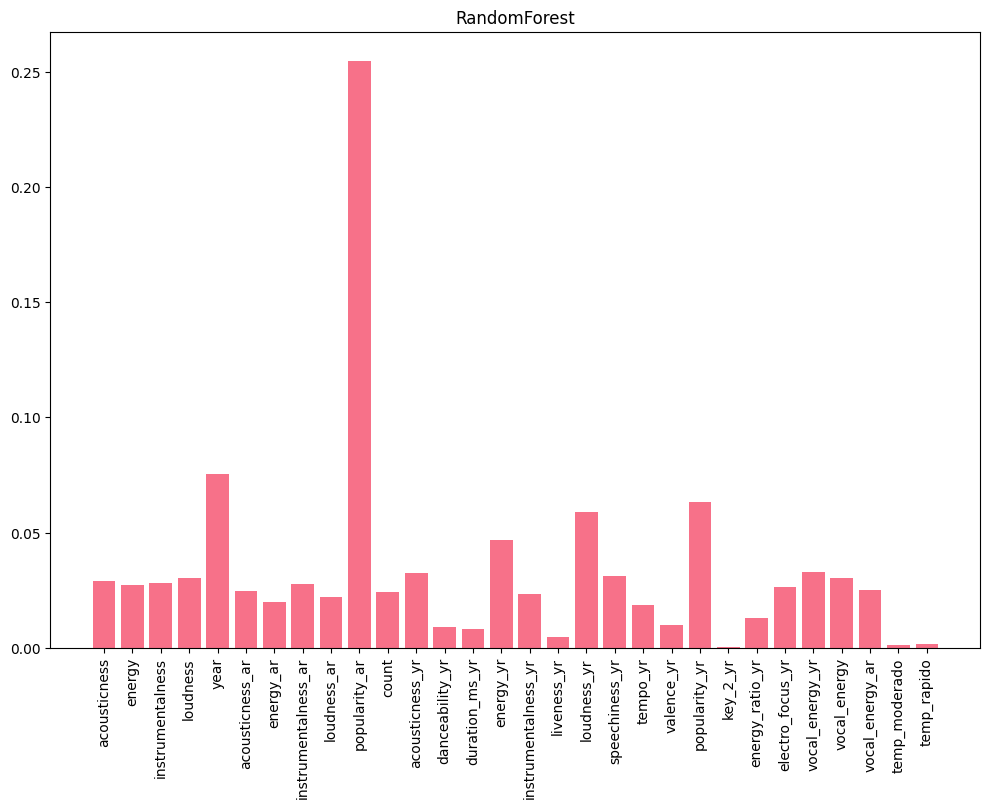

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.86      0.67      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



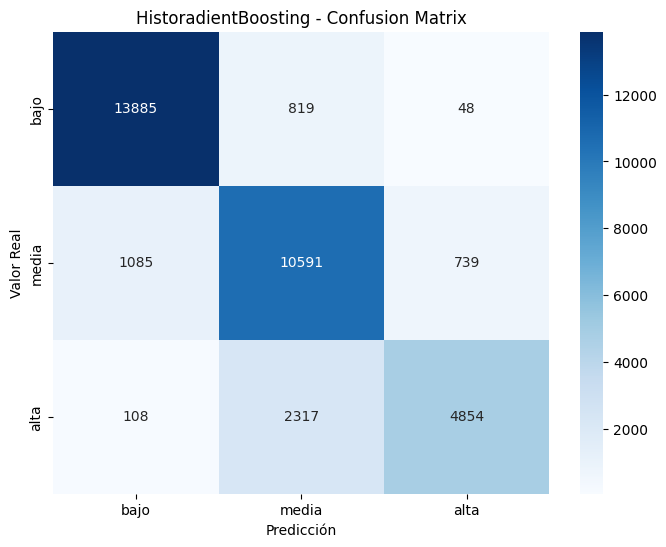

train

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     59010
           1       0.79      0.88      0.83     49659
           2       0.89      0.69      0.78     29115

    accuracy                           0.87    137784
   macro avg       0.87      0.84      0.85    137784
weighted avg       0.87      0.87      0.87    137784



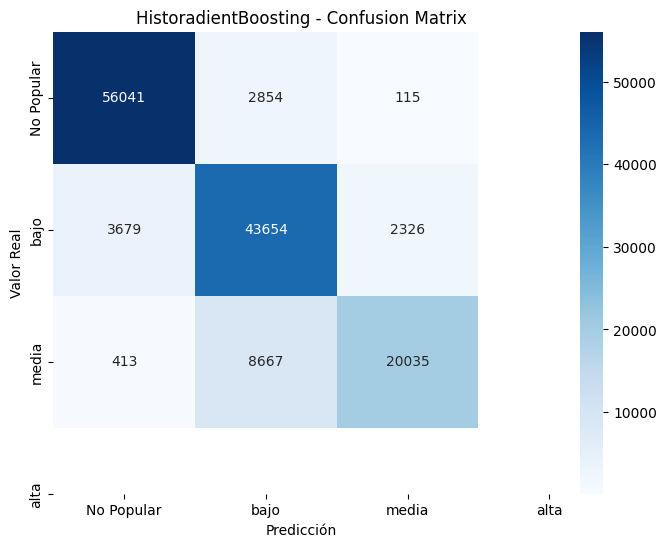

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.84      0.67      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



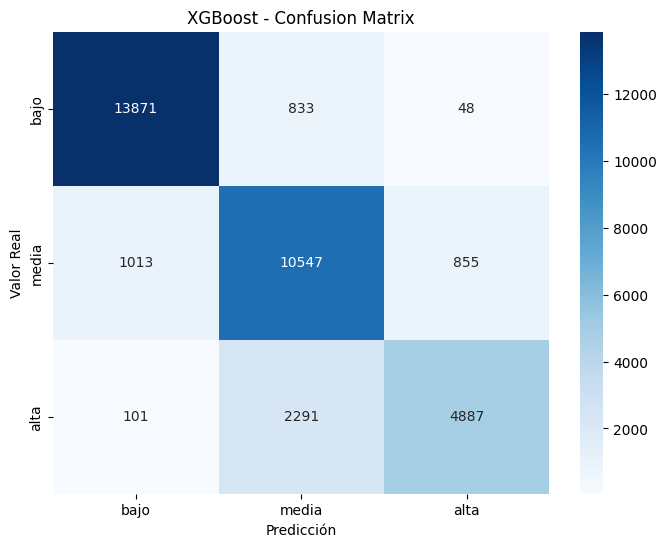

train

XGBoost
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     59010
           1       0.91      0.97      0.94     49659
           2       0.98      0.85      0.91     29115

    accuracy                           0.95    137784
   macro avg       0.96      0.94      0.95    137784
weighted avg       0.96      0.95      0.95    137784



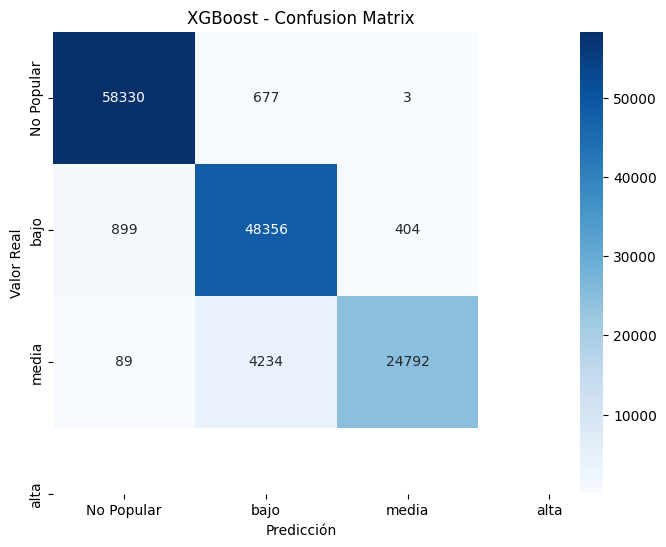

[0.00704615 0.00694919 0.0071809  0.00744251 0.04969354 0.0091841
 0.00896893 0.00897337 0.00894043 0.27152708 0.01395307 0.0335297
 0.01500779 0.0107563  0.02127126 0.06052694 0.00885085 0.01181493
 0.16677758 0.01163534 0.03348688 0.07818853 0.00959831 0.00852747
 0.00863552 0.1052679  0.00740239 0.00886295 0.         0.        ]


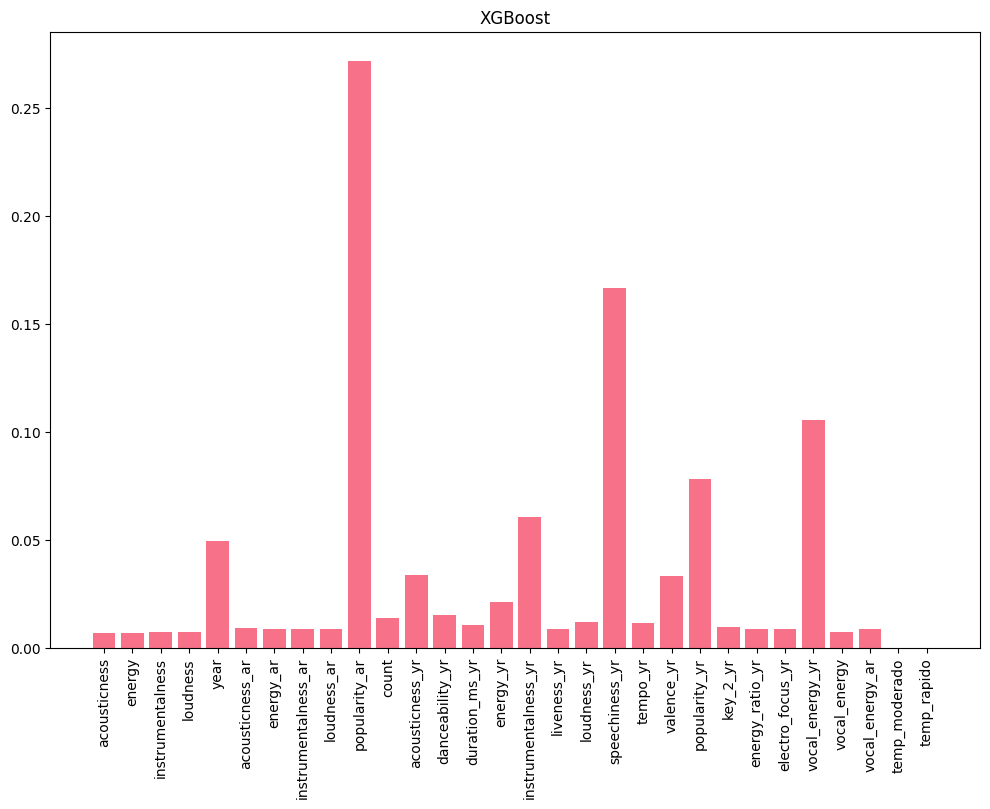

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14752
           1       0.78      0.83      0.80     12415
           2       0.81      0.70      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.84      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



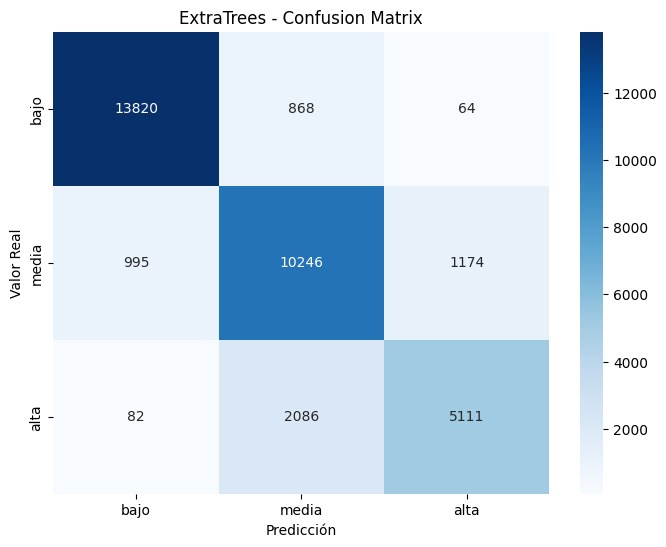

train

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     59010
           1       0.89      0.94      0.92     49659
           2       0.92      0.85      0.88     29115

    accuracy                           0.94    137784
   macro avg       0.93      0.92      0.93    137784
weighted avg       0.94      0.94      0.94    137784



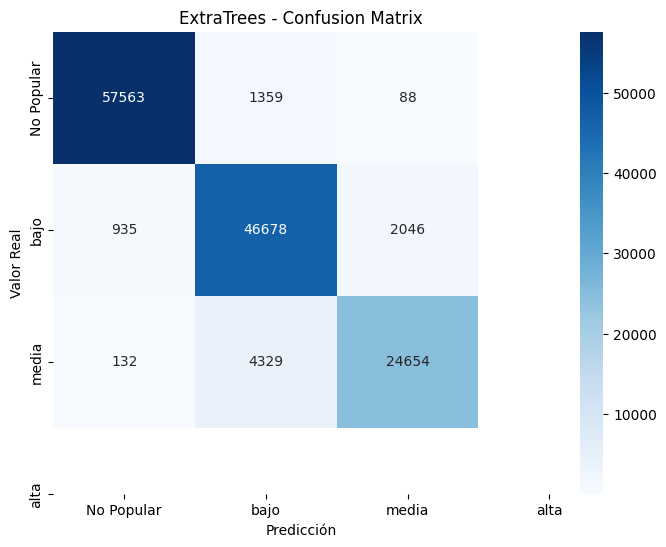

[0.02473717 0.01869988 0.02513407 0.01939646 0.05605368 0.02449754
 0.02034737 0.02851391 0.01781486 0.21832537 0.0220819  0.05282974
 0.01126806 0.0081335  0.06124049 0.02652397 0.00473109 0.05064131
 0.02382735 0.03107095 0.0208856  0.07679033 0.00372965 0.01071179
 0.03097421 0.04750646 0.02192229 0.0267988  0.00640084 0.00841137]


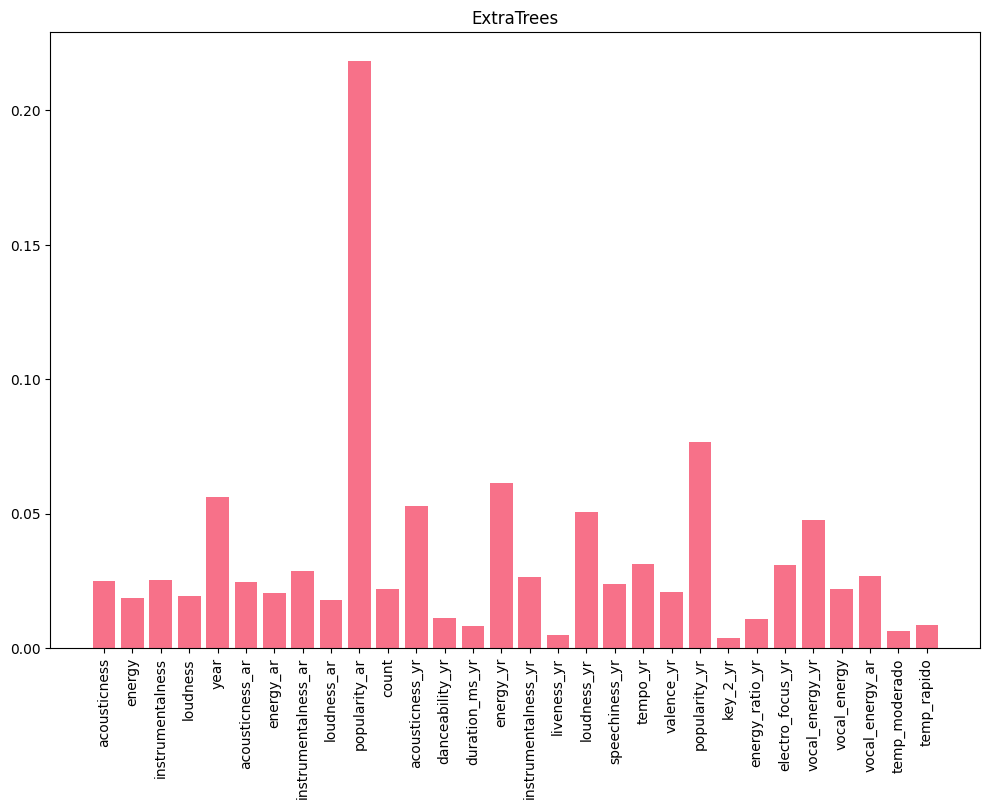

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.78      0.80      0.79     12415
           2       0.79      0.72      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.83      0.82      0.82     34446
weighted avg       0.84      0.84      0.84     34446



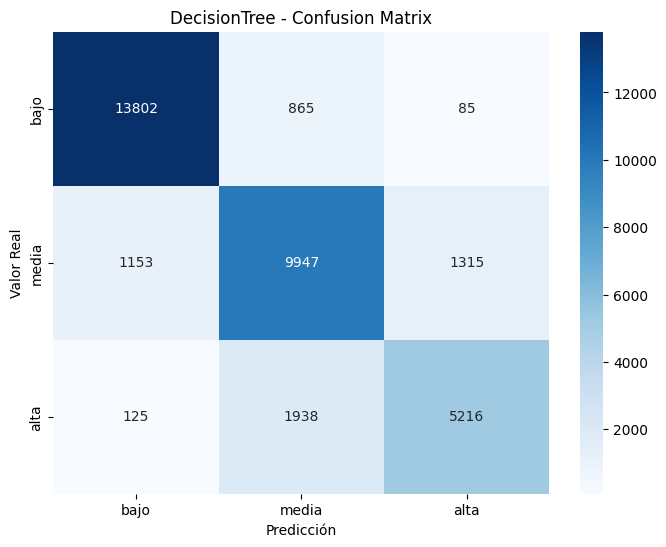

train

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     59010
           1       0.80      0.82      0.81     49659
           2       0.81      0.73      0.77     29115

    accuracy                           0.85    137784
   macro avg       0.84      0.83      0.84    137784
weighted avg       0.85      0.85      0.85    137784



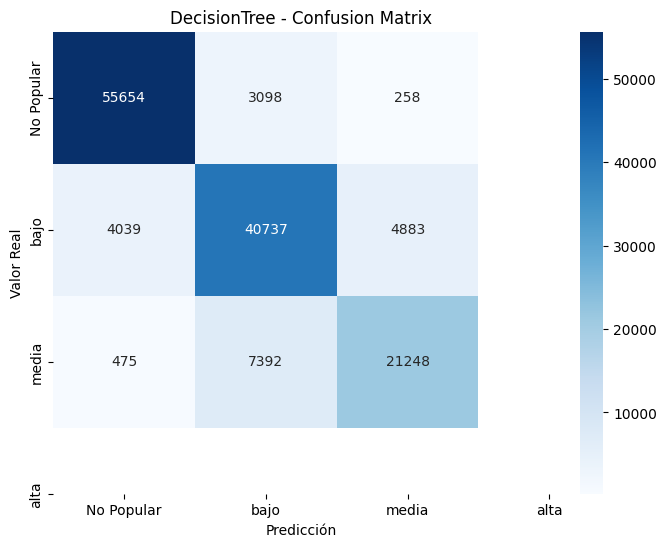

[2.66211719e-03 2.15002065e-03 1.53545907e-03 2.75196778e-03
 1.83134602e-02 3.26731596e-03 2.24537424e-03 4.38943840e-03
 3.29590633e-03 8.37643316e-01 1.61019924e-02 7.27819732e-03
 1.94637858e-03 2.09033408e-03 1.50212960e-03 1.66031628e-03
 7.92898233e-04 1.79224277e-02 2.67899927e-02 8.34255036e-04
 2.20467187e-04 3.34962320e-02 0.00000000e+00 4.19445877e-03
 6.12611964e-04 4.03725105e-04 2.67871604e-03 3.22049126e-03
 0.00000000e+00 0.00000000e+00]


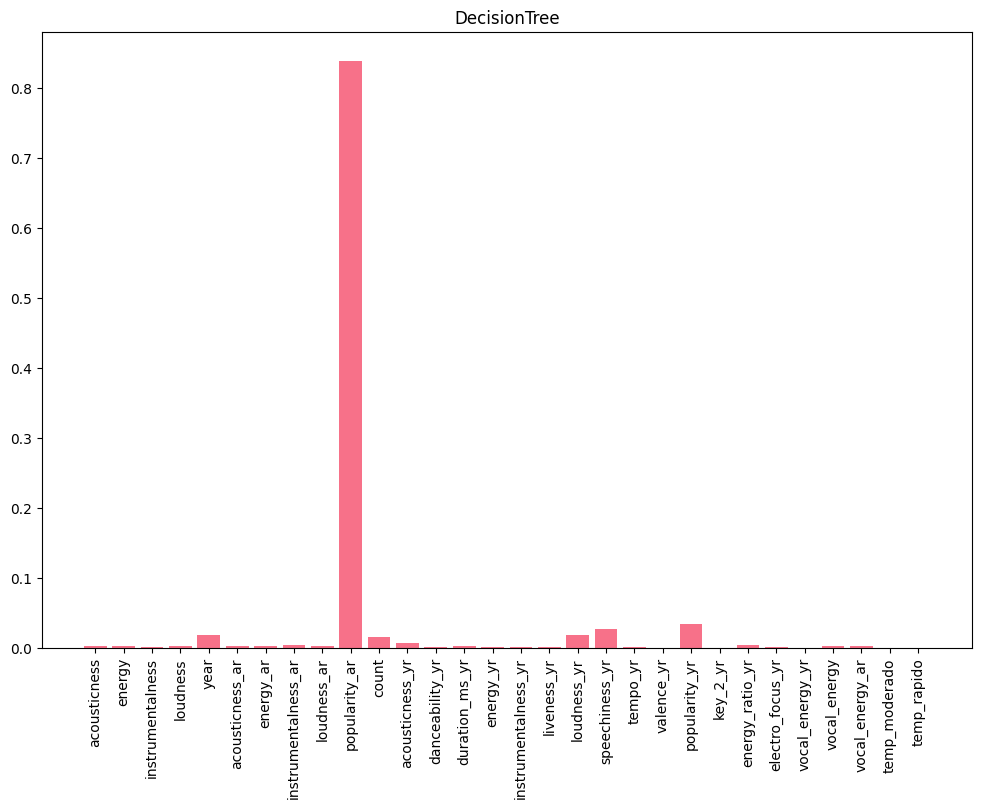

In [16]:
selector = SelectKBest(score_func=f_classif,k=30)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# k=20


Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.77      0.84      0.80     12415
           2       0.82      0.70      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.84      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



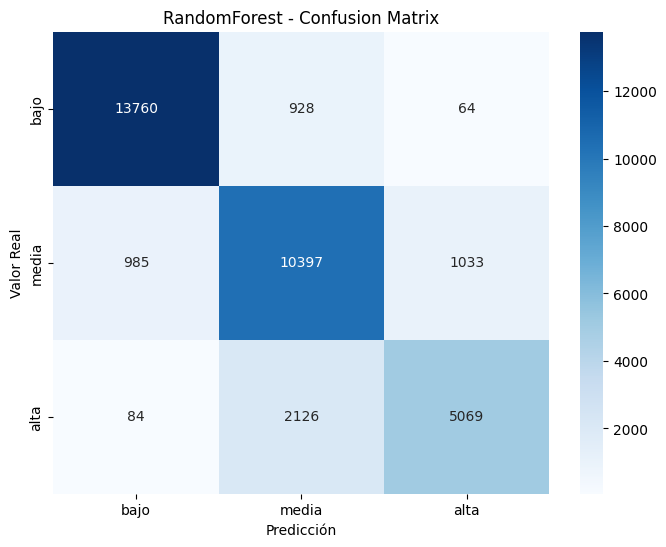

train

RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     59010
           1       0.90      0.98      0.93     49659
           2       0.97      0.85      0.91     29115

    accuracy                           0.95    137784
   macro avg       0.95      0.94      0.94    137784
weighted avg       0.95      0.95      0.95    137784



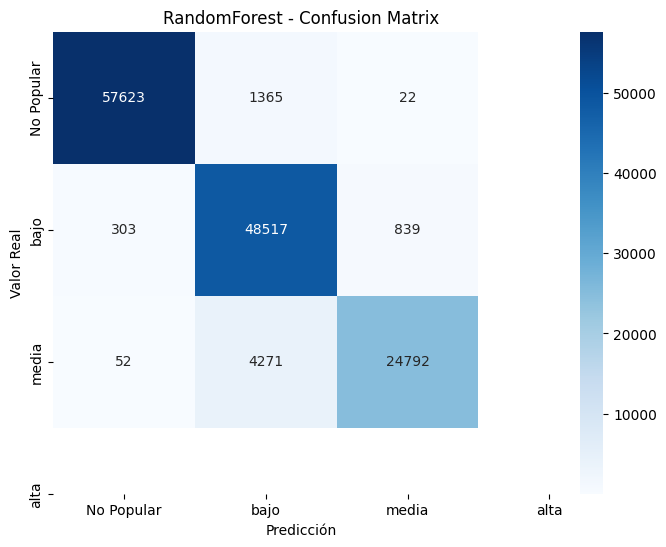

[0.05361642 0.08916552 0.02824451 0.02470629 0.0342981  0.02834857
 0.29547802 0.03121796 0.00681333 0.04967973 0.01793812 0.05070532
 0.03071051 0.02359641 0.01430639 0.06522981 0.02649356 0.04286445
 0.05747354 0.02911343]


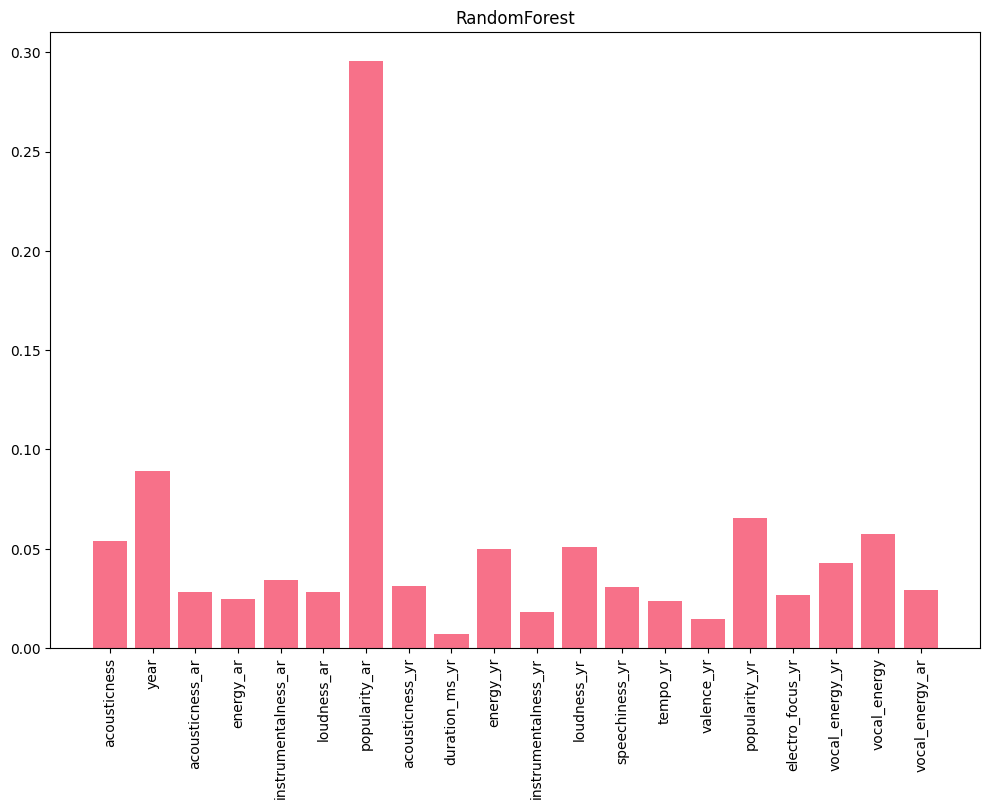

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.86      0.66      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



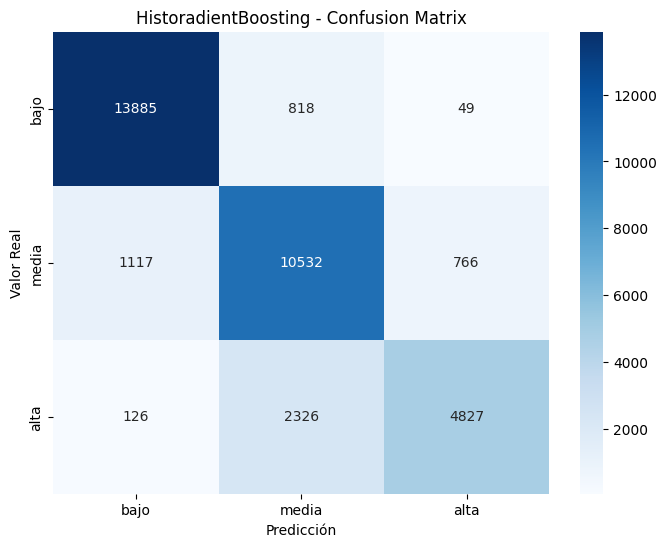

train

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     59010
           1       0.78      0.87      0.83     49659
           2       0.88      0.68      0.77     29115

    accuracy                           0.86    137784
   macro avg       0.86      0.83      0.84    137784
weighted avg       0.87      0.86      0.86    137784



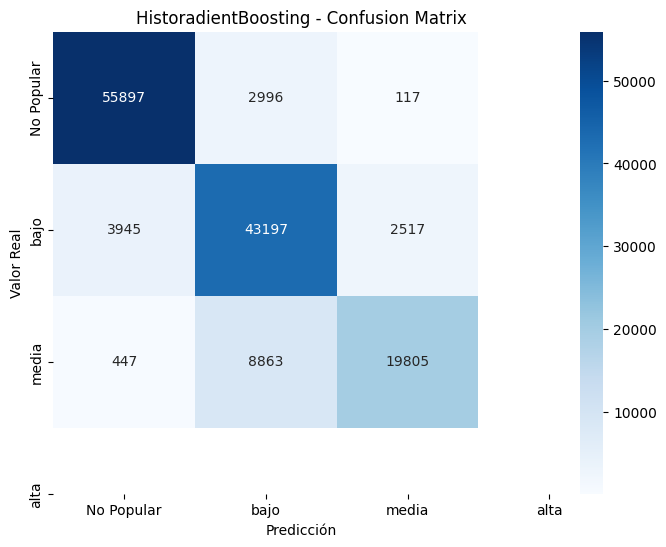

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.84      0.67      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



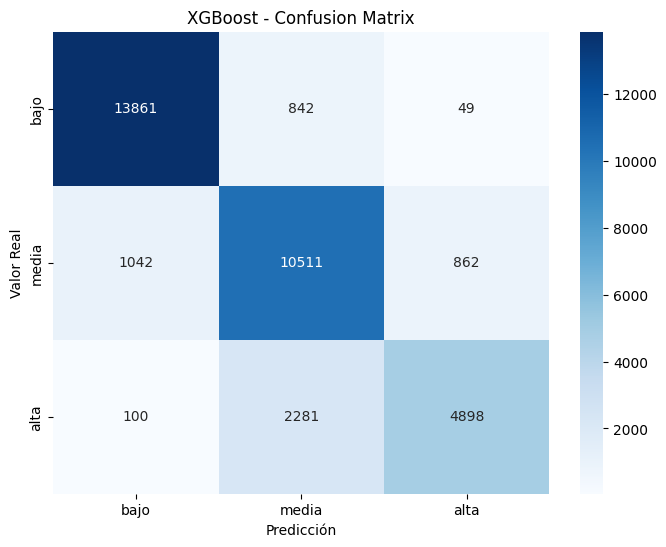

train

XGBoost
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     59010
           1       0.88      0.96      0.92     49659
           2       0.98      0.81      0.89     29115

    accuracy                           0.94    137784
   macro avg       0.94      0.92      0.93    137784
weighted avg       0.94      0.94      0.94    137784



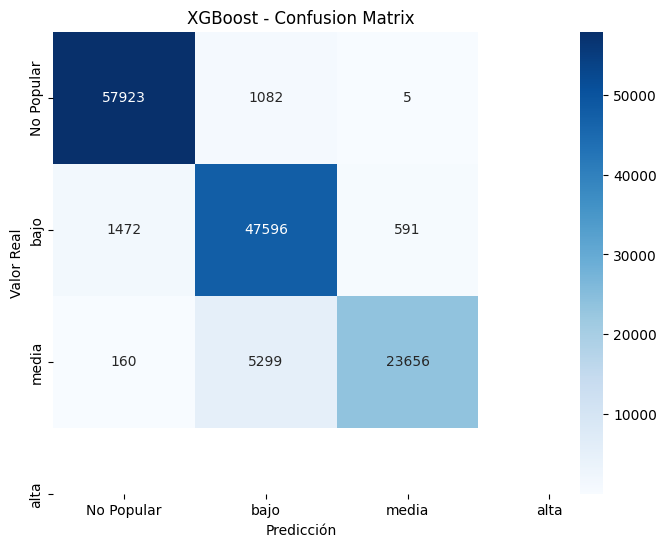

[0.00850376 0.05606929 0.01137503 0.01109808 0.01228025 0.01121276
 0.28897846 0.02975433 0.01253692 0.02354978 0.06601332 0.01290974
 0.17450592 0.01394376 0.03432595 0.08350907 0.01106841 0.11813918
 0.00851203 0.01171395]


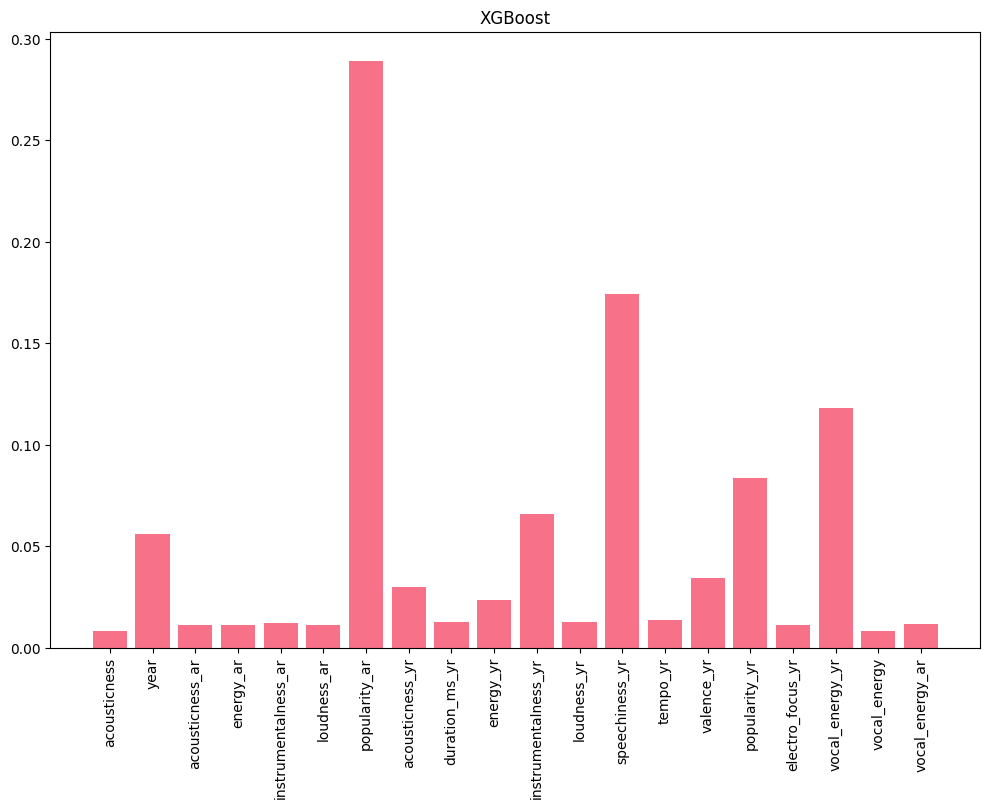

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.77      0.82      0.80     12415
           2       0.80      0.70      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.83      0.82      0.83     34446
weighted avg       0.85      0.85      0.84     34446



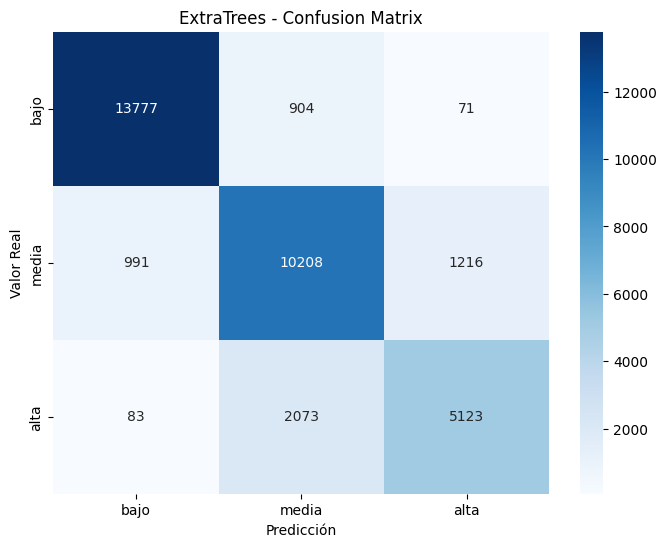

train

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     59010
           1       0.88      0.94      0.91     49659
           2       0.92      0.83      0.87     29115

    accuracy                           0.93    137784
   macro avg       0.93      0.91      0.92    137784
weighted avg       0.93      0.93      0.93    137784



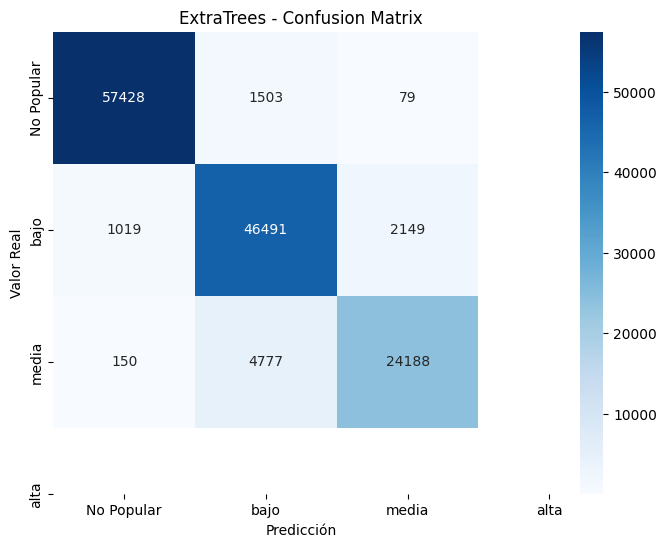

[0.0355862  0.06475637 0.03308801 0.02313904 0.03651588 0.02405638
 0.25664253 0.05203432 0.01091923 0.05721953 0.03860386 0.06286887
 0.02300386 0.02894559 0.02303168 0.07388701 0.03305616 0.05390289
 0.03571133 0.03303124]


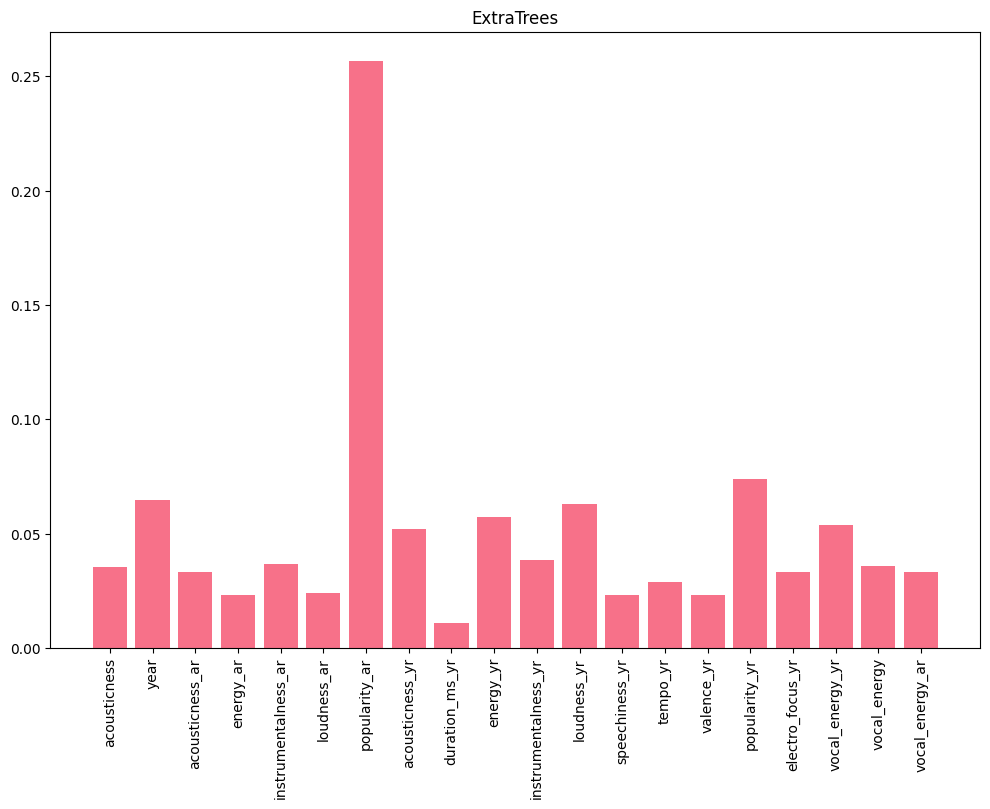

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     14752
           1       0.78      0.78      0.78     12415
           2       0.76      0.73      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.82      0.82      0.82     34446
weighted avg       0.84      0.84      0.84     34446



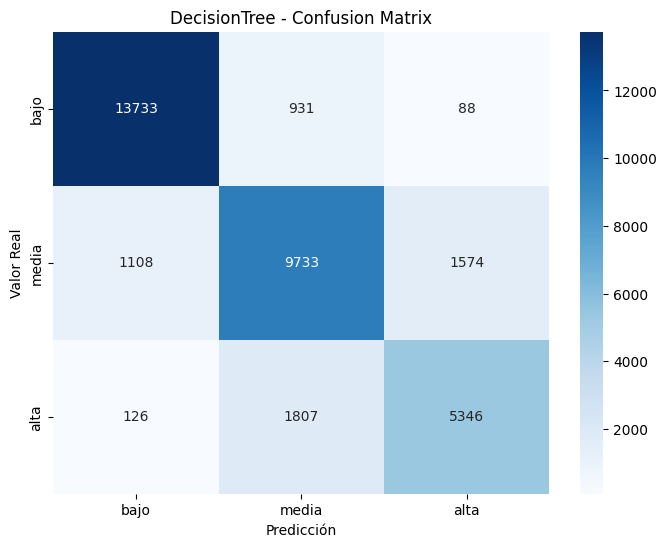

train

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     59010
           1       0.79      0.81      0.80     49659
           2       0.78      0.75      0.76     29115

    accuracy                           0.85    137784
   macro avg       0.83      0.83      0.83    137784
weighted avg       0.85      0.85      0.85    137784



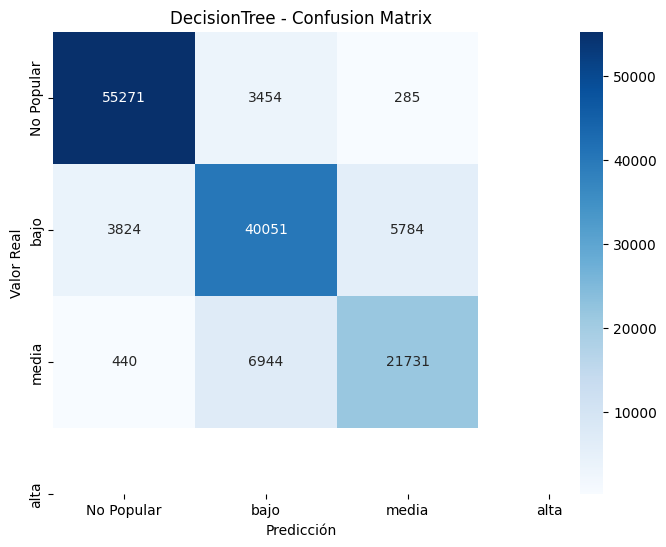

[3.60498485e-03 1.74528380e-02 4.66523586e-03 2.82526196e-03
 8.57998880e-03 4.02948859e-03 8.45945855e-01 1.80242006e-03
 2.75120697e-03 2.25418099e-03 8.42270752e-03 1.89705240e-02
 2.92351025e-02 1.10694113e-03 6.44205885e-04 3.62491463e-02
 9.87989237e-04 2.53298889e-04 4.85887762e-03 5.35974576e-03]


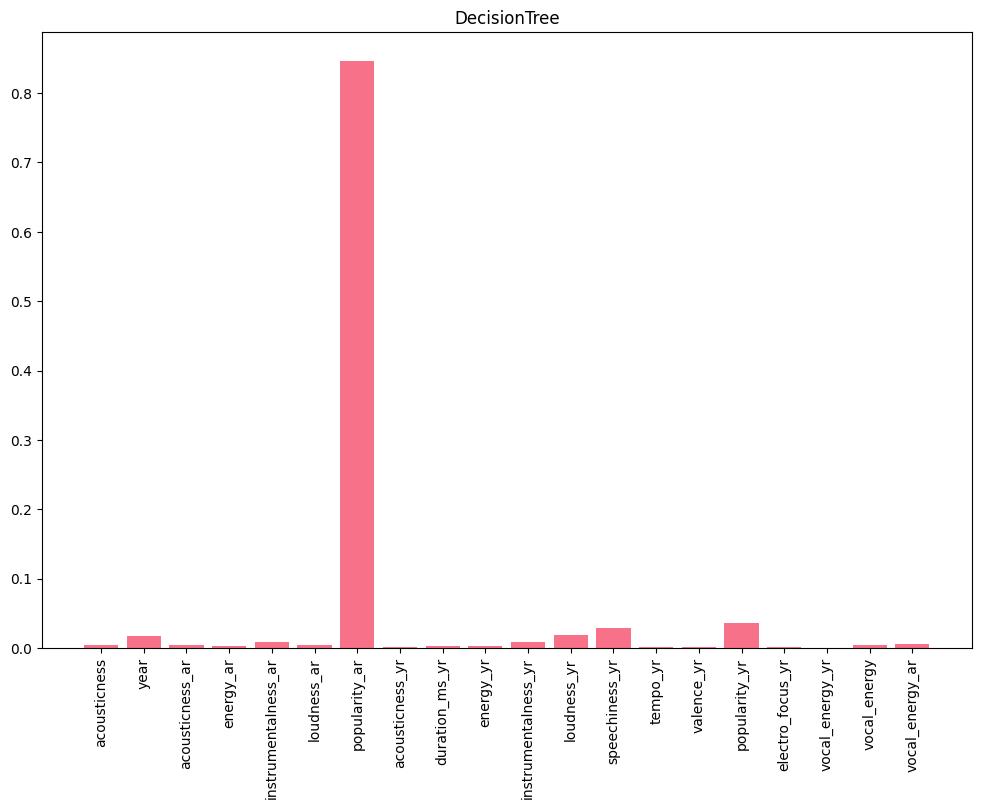

In [17]:
selector = SelectKBest(score_func=f_classif,k=20)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# k=10


Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': 10, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.77      0.82      0.80     12415
           2       0.80      0.71      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.83      0.82      0.83     34446
weighted avg       0.84      0.84      0.84     34446



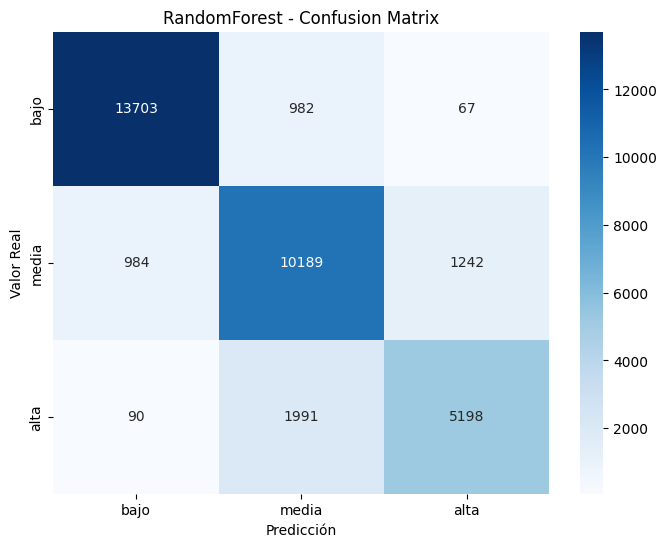

train

RandomForest
Best params: {'max_depth': 10, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     59010
           1       0.78      0.83      0.81     49659
           2       0.81      0.72      0.76     29115

    accuracy                           0.85    137784
   macro avg       0.84      0.83      0.83    137784
weighted avg       0.85      0.85      0.85    137784



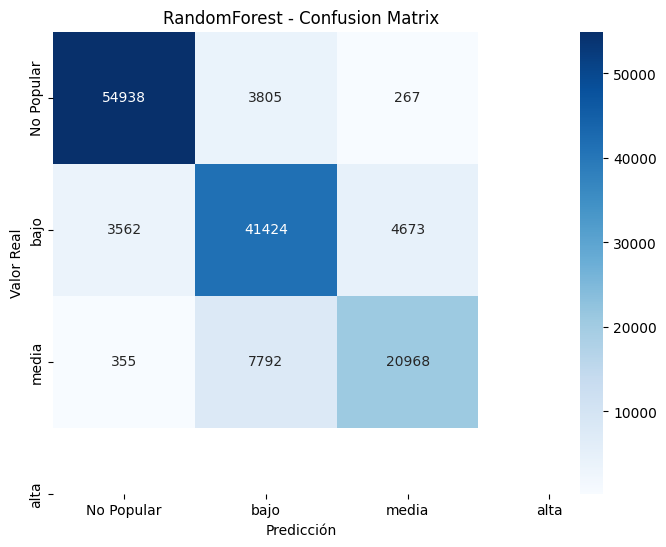

[0.15025173 0.45314806 0.03313527 0.05681083 0.01635905 0.0644288
 0.02030403 0.11930099 0.05930976 0.02695149]


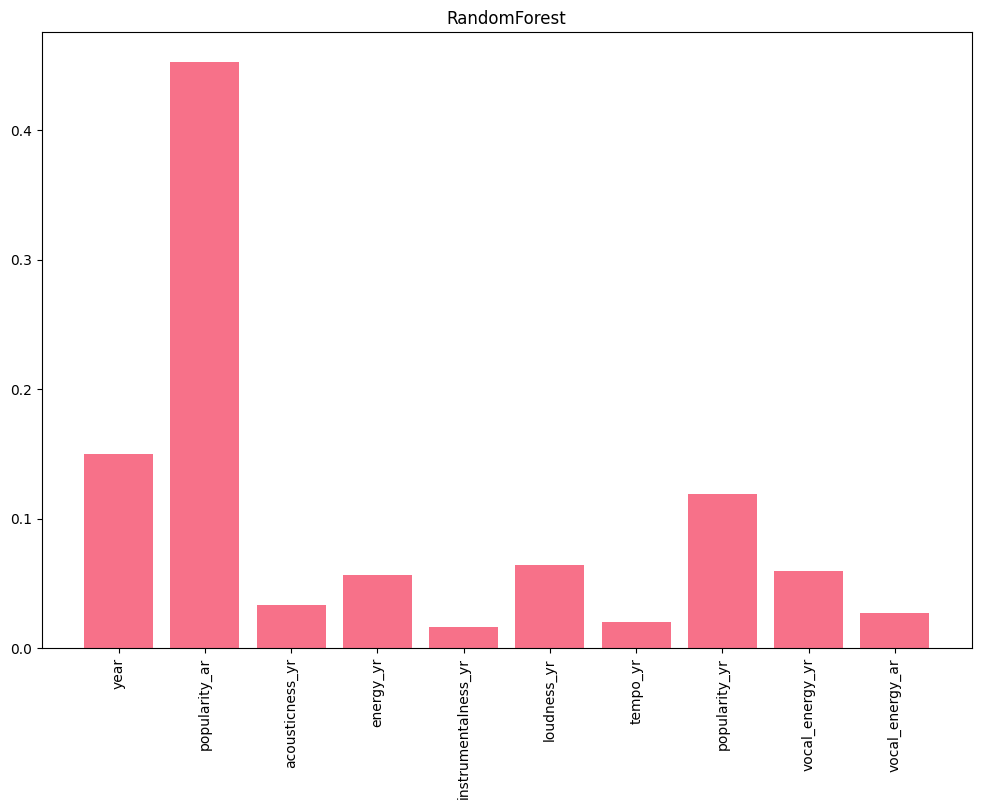

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.86      0.66      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



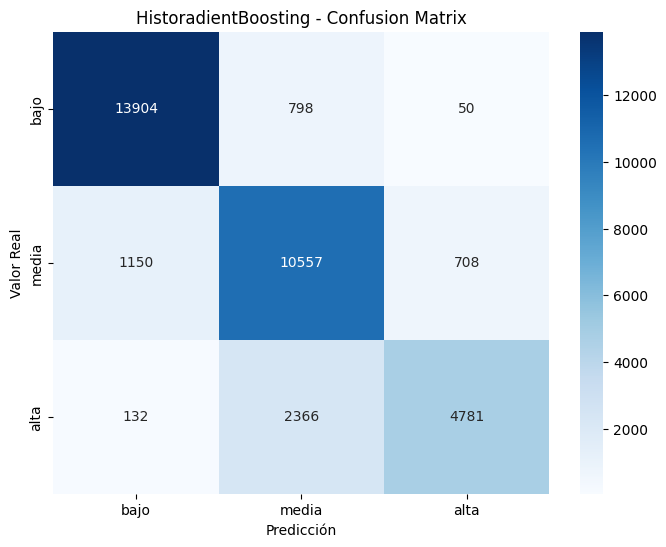

train

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.92      0.95      0.94     59010
           1       0.78      0.87      0.82     49659
           2       0.88      0.67      0.76     29115

    accuracy                           0.86    137784
   macro avg       0.86      0.83      0.84    137784
weighted avg       0.86      0.86      0.86    137784



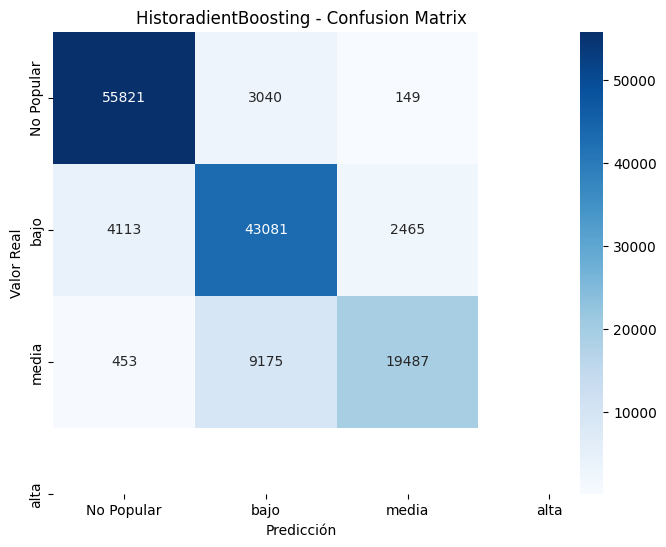

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14752
           1       0.77      0.85      0.81     12415
           2       0.85      0.67      0.75      7279

    accuracy                           0.85     34446
   macro avg       0.85      0.82      0.83     34446
weighted avg       0.85      0.85      0.85     34446



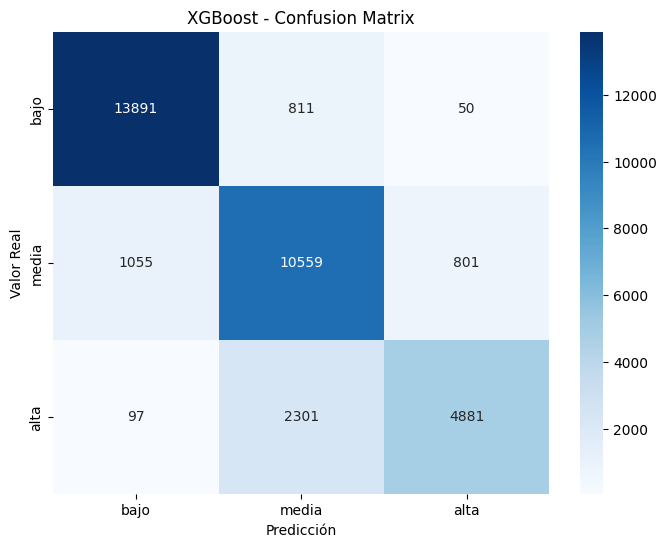

train

XGBoost
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     59010
           1       0.81      0.90      0.85     49659
           2       0.91      0.72      0.81     29115

    accuracy                           0.89    137784
   macro avg       0.89      0.86      0.87    137784
weighted avg       0.89      0.89      0.88    137784



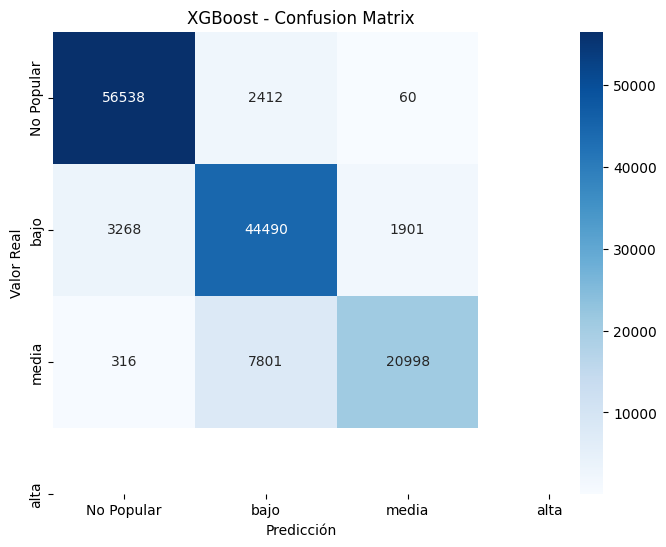

[0.09262085 0.2850337  0.04080378 0.03112335 0.25754997 0.02272823
 0.02281449 0.06355421 0.16584192 0.01792951]


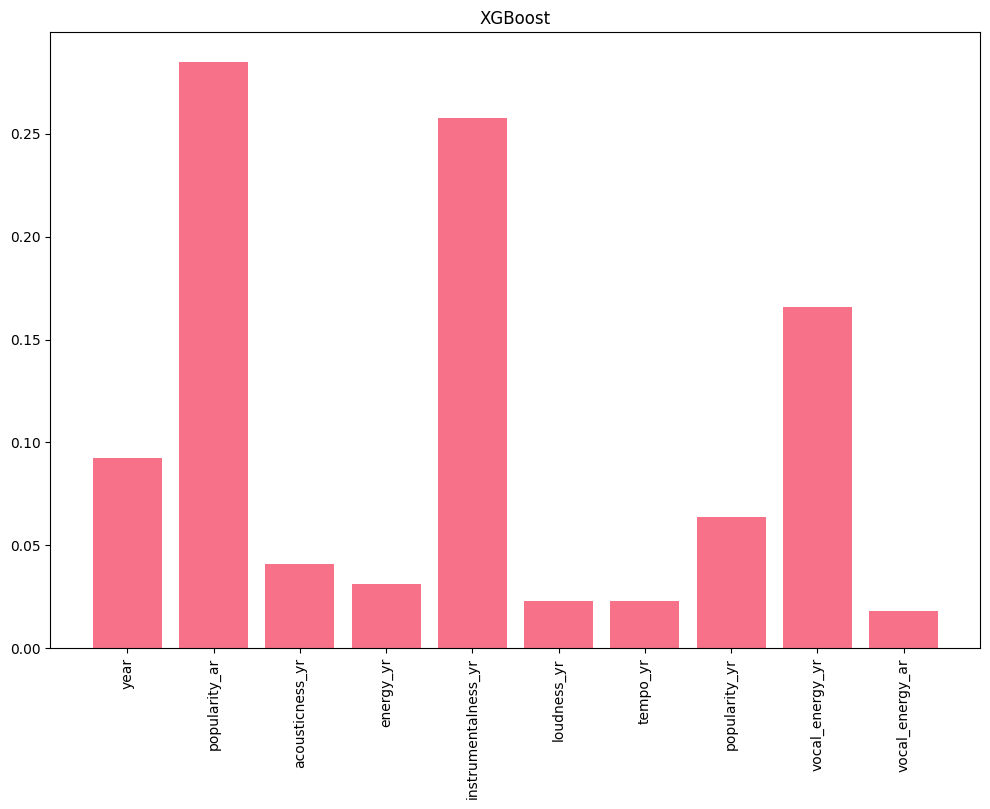

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     14752
           1       0.78      0.82      0.80     12415
           2       0.79      0.72      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.83      0.82      0.83     34446
weighted avg       0.84      0.84      0.84     34446



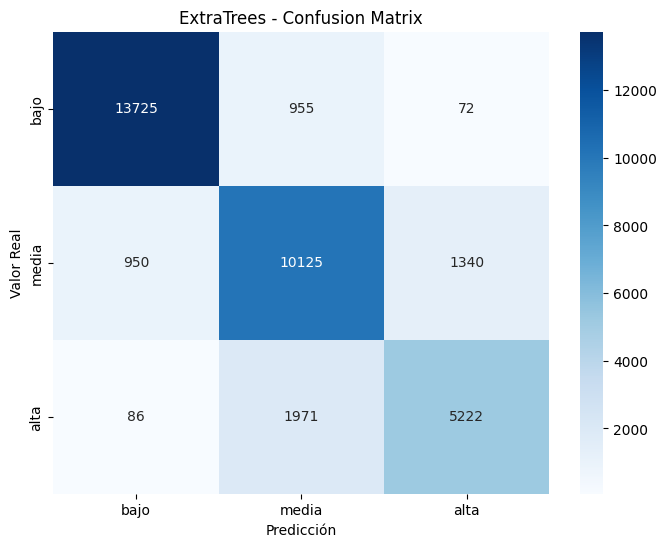

train

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     59010
           1       0.83      0.88      0.85     49659
           2       0.86      0.78      0.82     29115

    accuracy                           0.89    137784
   macro avg       0.88      0.87      0.88    137784
weighted avg       0.89      0.89      0.89    137784



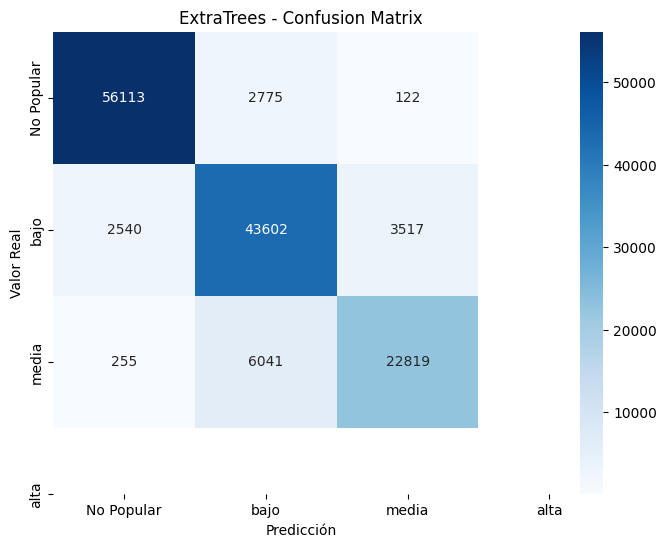

[0.0717221  0.3986028  0.06915097 0.08514324 0.0273345  0.05629907
 0.04437825 0.11305253 0.05681201 0.07750455]


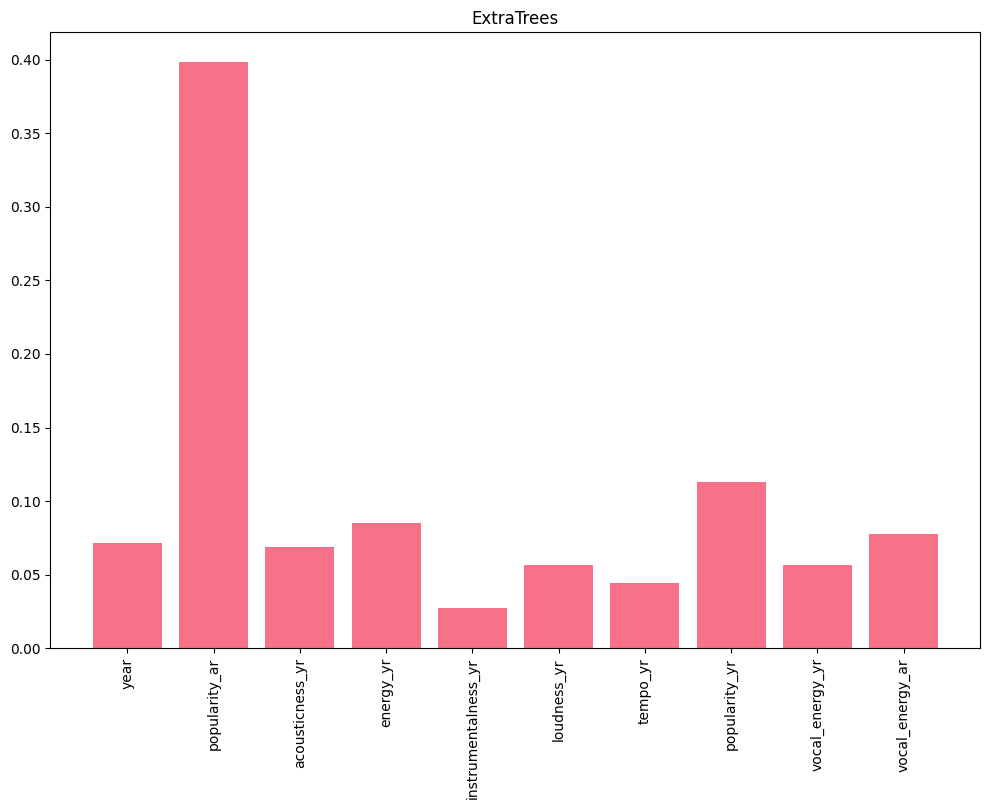

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     14752
           1       0.77      0.79      0.78     12415
           2       0.77      0.73      0.75      7279

    accuracy                           0.84     34446
   macro avg       0.82      0.82      0.82     34446
weighted avg       0.84      0.84      0.84     34446



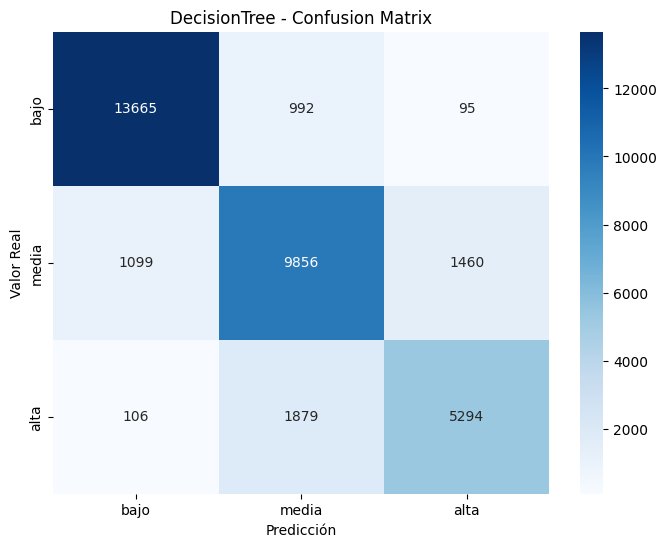

train

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     59010
           1       0.79      0.81      0.80     49659
           2       0.79      0.74      0.76     29115

    accuracy                           0.85    137784
   macro avg       0.83      0.83      0.83    137784
weighted avg       0.85      0.85      0.85    137784



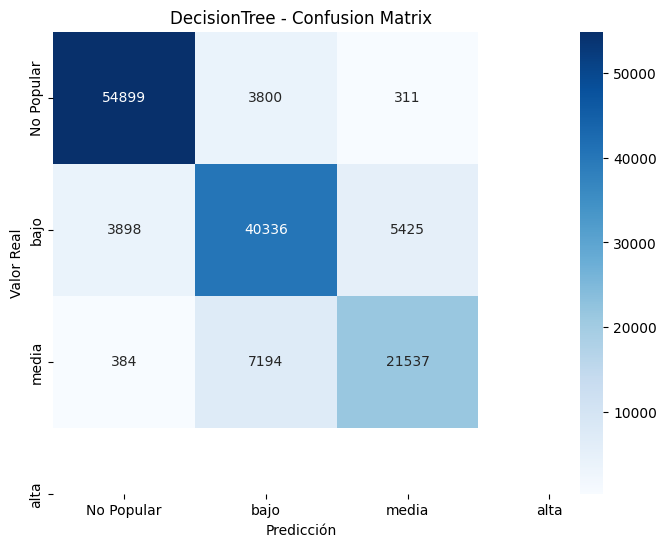

[0.01971119 0.87910225 0.00368977 0.00374572 0.01470799 0.0218583
 0.00209585 0.03892591 0.0014756  0.01468743]


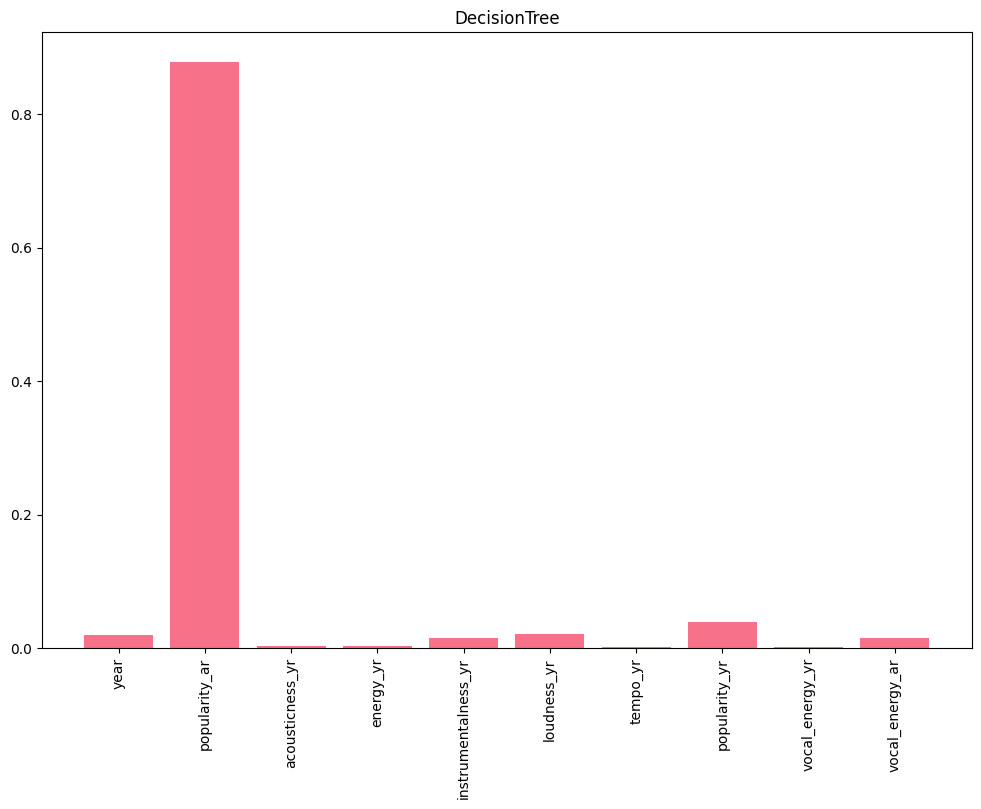

In [18]:
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# PCA n=2

Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.70      0.69      0.69     14752
           1       0.55      0.50      0.52     12415
           2       0.42      0.49      0.45      7279

    accuracy                           0.58     34446
   macro avg       0.55      0.56      0.56     34446
weighted avg       0.59      0.58      0.58     34446



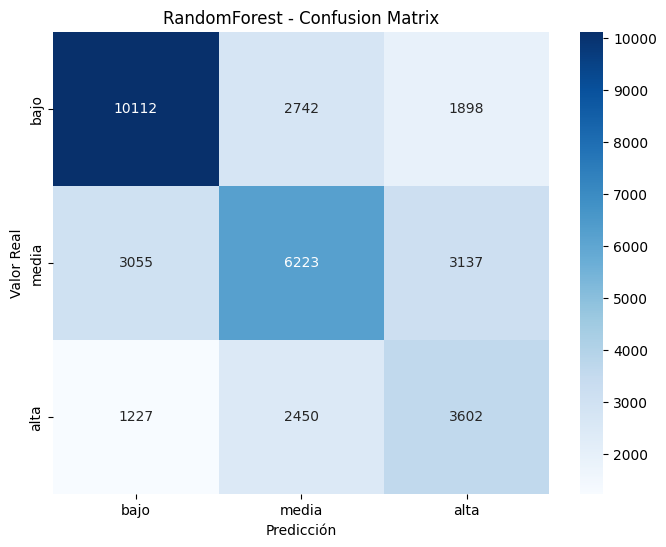

train

RandomForest
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.71      0.69      0.70     59010
           1       0.56      0.52      0.54     49659
           2       0.44      0.51      0.47     29115

    accuracy                           0.59    137784
   macro avg       0.57      0.58      0.57    137784
weighted avg       0.60      0.59      0.60    137784



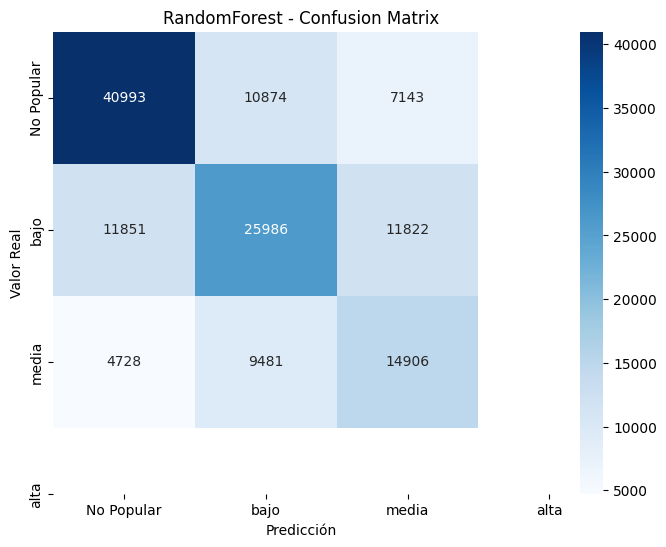

[0.55064064 0.44935936]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).
Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 3, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.67      0.73      0.70     14752
           1       0.54      0.58      0.56     12415
           2       0.47      0.32      0.38      7279

    accuracy                           0.59     34446
   macro avg       0.56      0.55      0.55     34446
weighted avg       0.58      0.59      0.58     34446



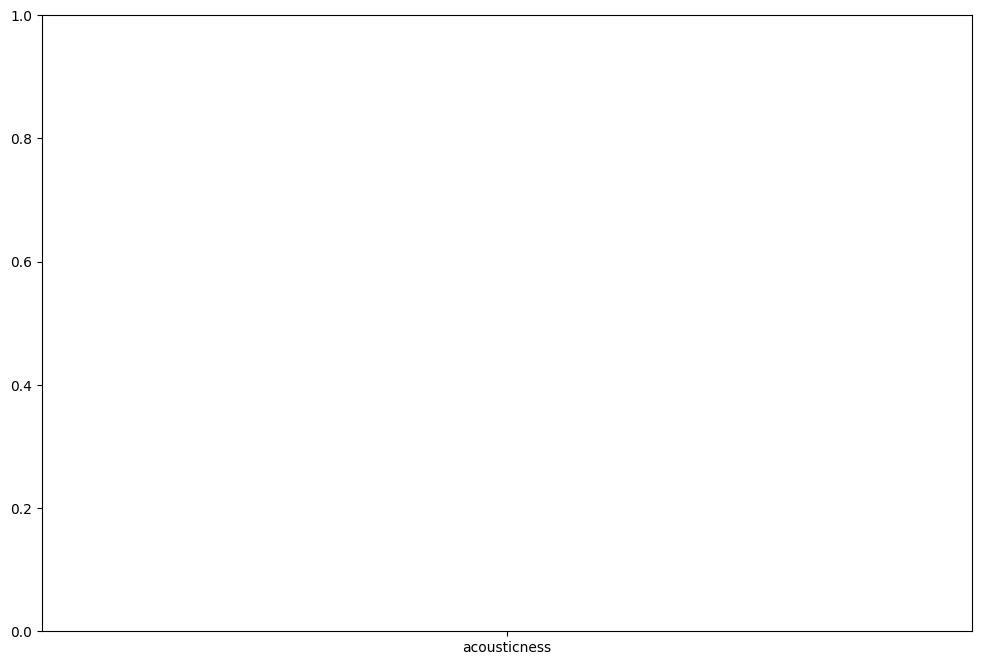

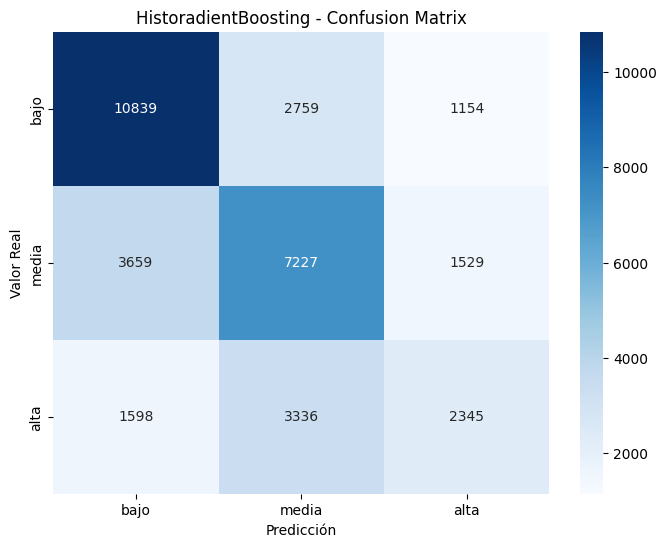

train

HistoradientBoosting
Best params: {'max_depth': 3, 'max_iter': 200}
              precision    recall  f1-score   support

           0       0.68      0.74      0.71     59010
           1       0.54      0.59      0.56     49659
           2       0.48      0.33      0.39     29115

    accuracy                           0.60    137784
   macro avg       0.57      0.55      0.55    137784
weighted avg       0.59      0.60      0.59    137784



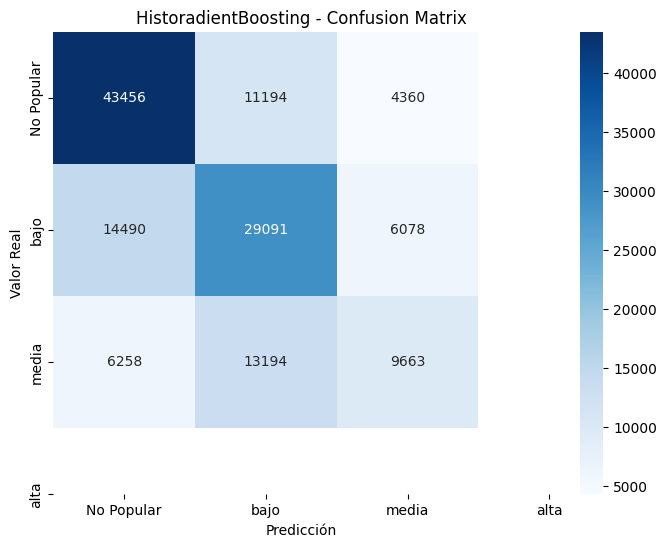

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.68      0.73      0.70     14752
           1       0.54      0.59      0.57     12415
           2       0.47      0.32      0.38      7279

    accuracy                           0.59     34446
   macro avg       0.56      0.55      0.55     34446
weighted avg       0.58      0.59      0.59     34446



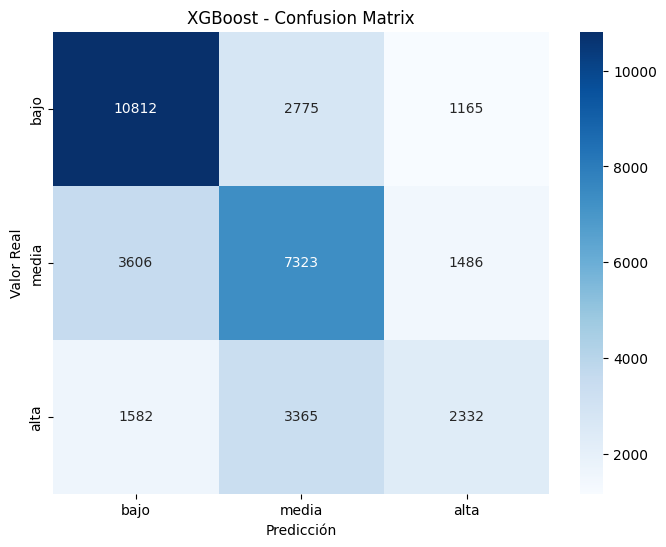

train

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.68      0.73      0.70     59010
           1       0.54      0.59      0.56     49659
           2       0.48      0.33      0.39     29115

    accuracy                           0.60    137784
   macro avg       0.57      0.55      0.55    137784
weighted avg       0.59      0.60      0.59    137784



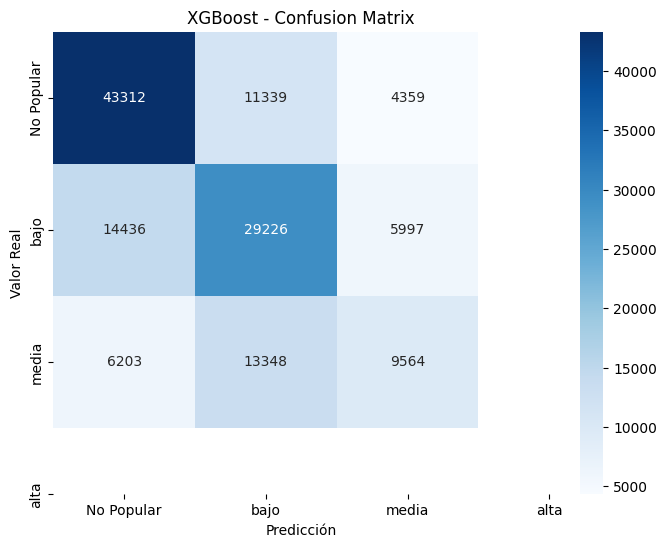

[0.42626932 0.5737307 ]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).
Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.71      0.66      0.68     14752
           1       0.54      0.49      0.51     12415
           2       0.41      0.52      0.46      7279

    accuracy                           0.57     34446
   macro avg       0.55      0.56      0.55     34446
weighted avg       0.58      0.57      0.57     34446



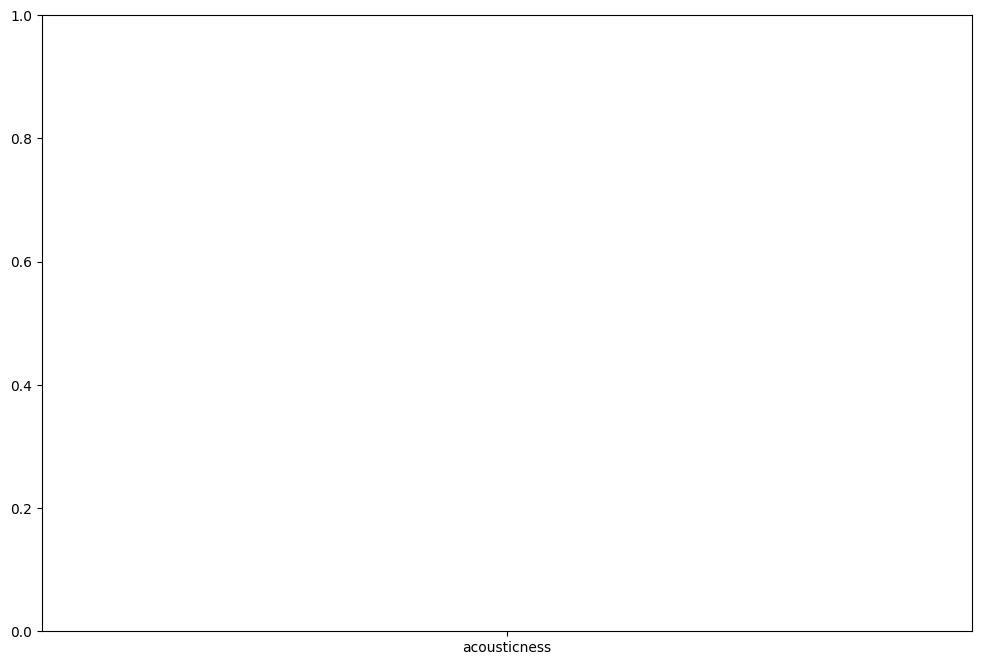

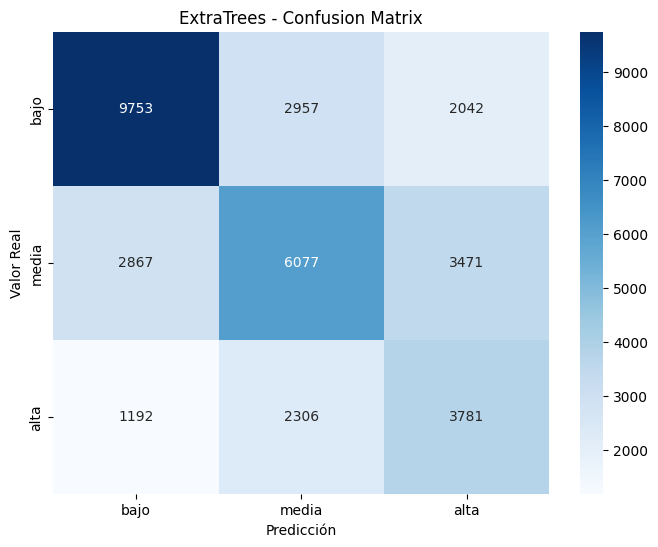

train

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.81      0.74      0.77     59010
           1       0.68      0.61      0.64     49659
           2       0.51      0.69      0.59     29115

    accuracy                           0.68    137784
   macro avg       0.67      0.68      0.67    137784
weighted avg       0.70      0.68      0.69    137784



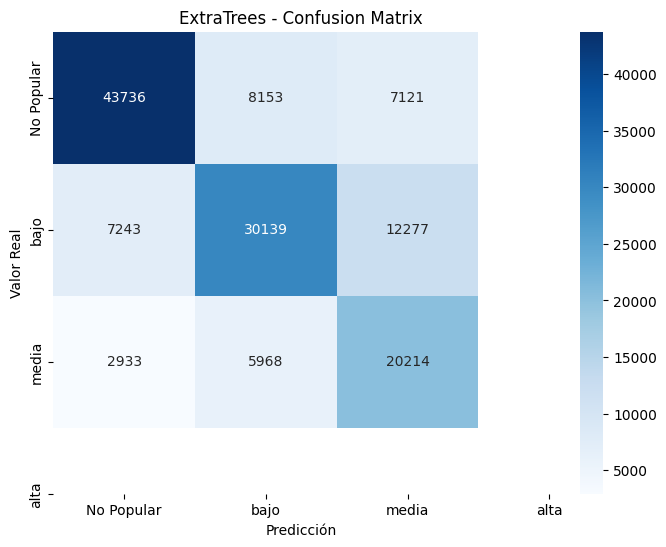

[0.42620124 0.57379876]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).
Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.71      0.65      0.68     14752
           1       0.53      0.51      0.52     12415
           2       0.41      0.49      0.45      7279

    accuracy                           0.57     34446
   macro avg       0.55      0.55      0.55     34446
weighted avg       0.58      0.57      0.57     34446



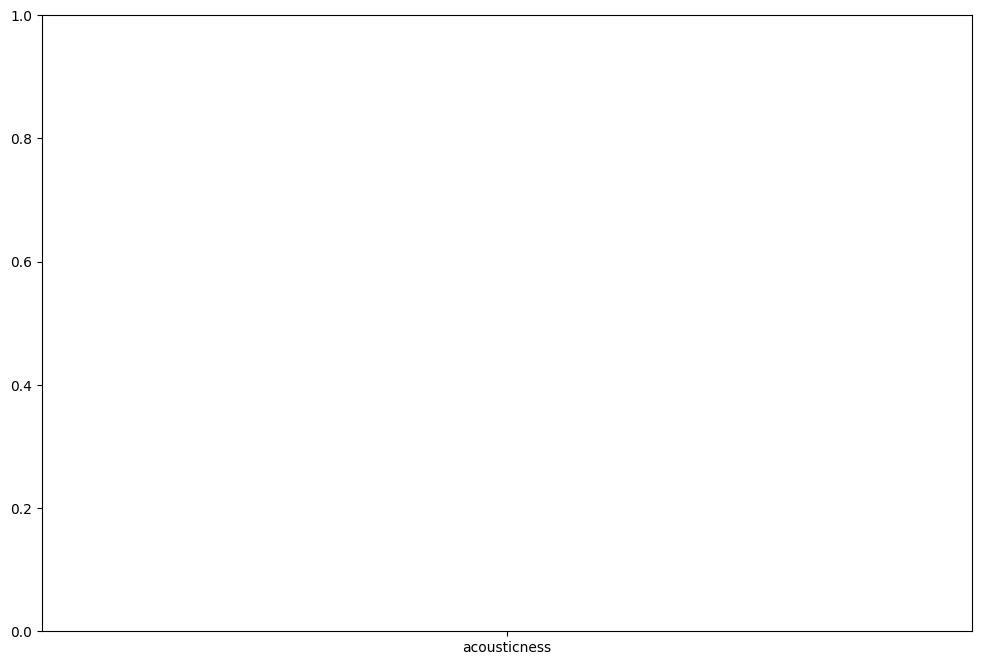

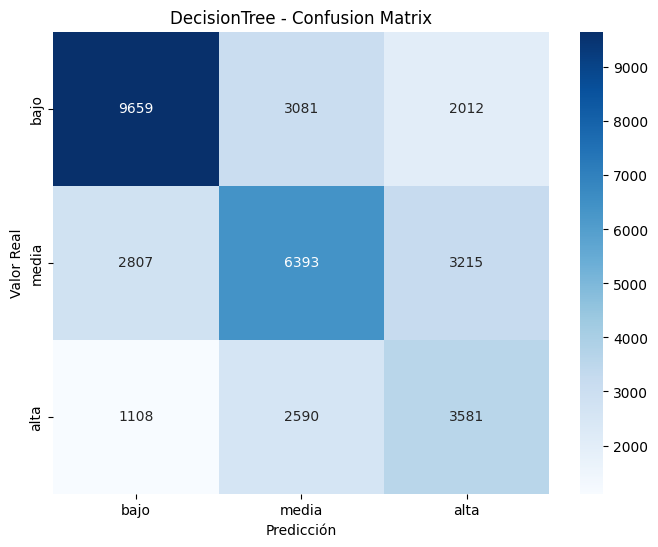

train

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.73      0.67      0.70     59010
           1       0.55      0.54      0.55     49659
           2       0.43      0.52      0.47     29115

    accuracy                           0.59    137784
   macro avg       0.57      0.58      0.57    137784
weighted avg       0.60      0.59      0.59    137784



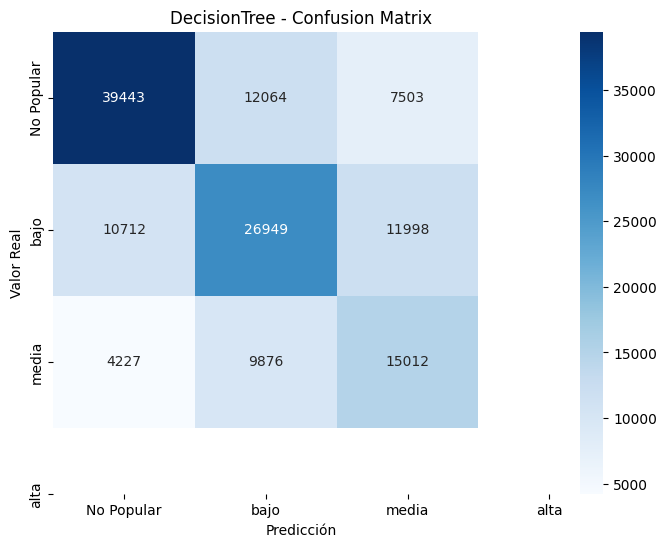

[0.49975406 0.50024594]
error shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (82,) and arg 1 with shape (2,).


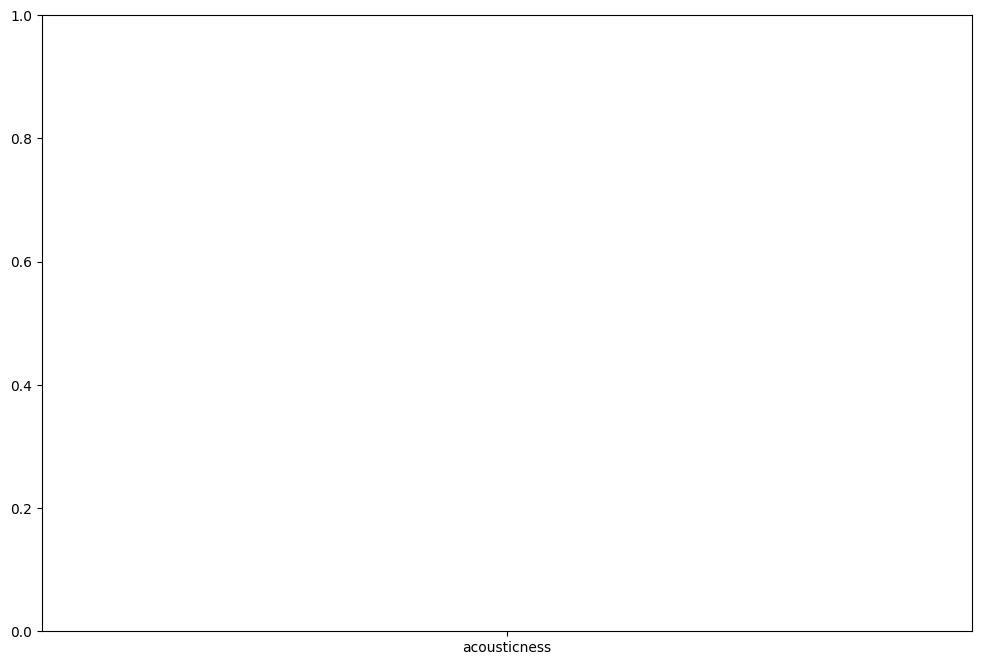

In [19]:
from sklearn.decomposition import PCA
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=2)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# PCA n=85%

Fitting 5 folds for each of 9 candidates, totalling 45 fits

RandomForest
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.63      0.53      0.58     14752
           1       0.44      0.45      0.45     12415
           2       0.37      0.48      0.42      7279

    accuracy                           0.49     34446
   macro avg       0.48      0.49      0.48     34446
weighted avg       0.51      0.49      0.50     34446



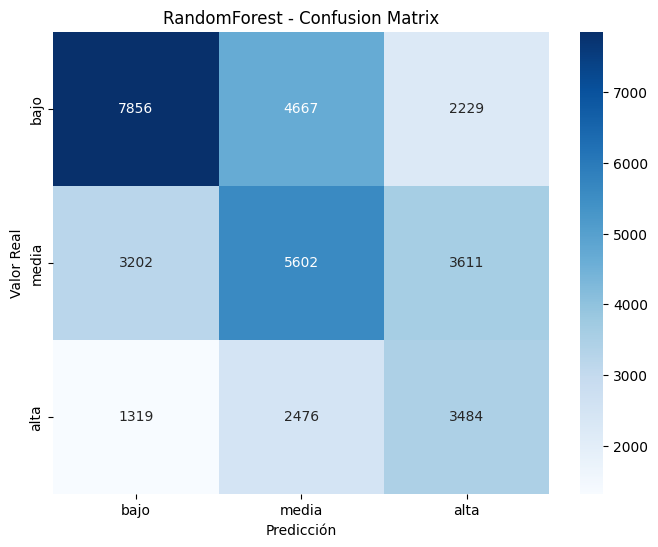

train

RandomForest
Best params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.65      0.54      0.59     59010
           1       0.46      0.48      0.47     49659
           2       0.40      0.50      0.44     29115

    accuracy                           0.51    137784
   macro avg       0.50      0.51      0.50    137784
weighted avg       0.53      0.51      0.52    137784



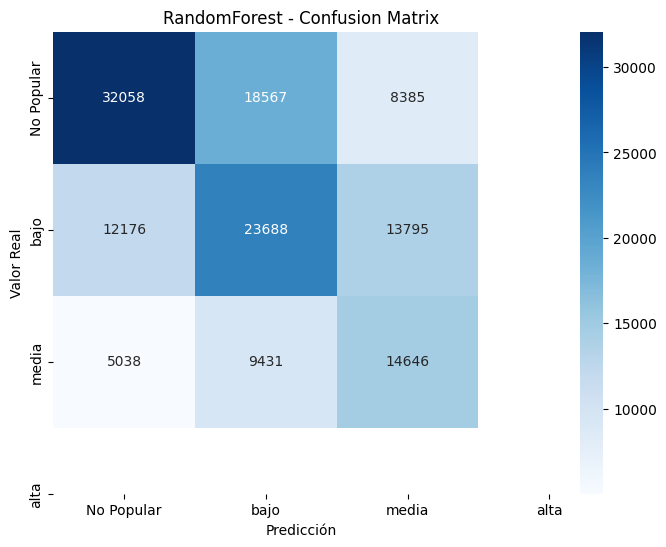

[1.]


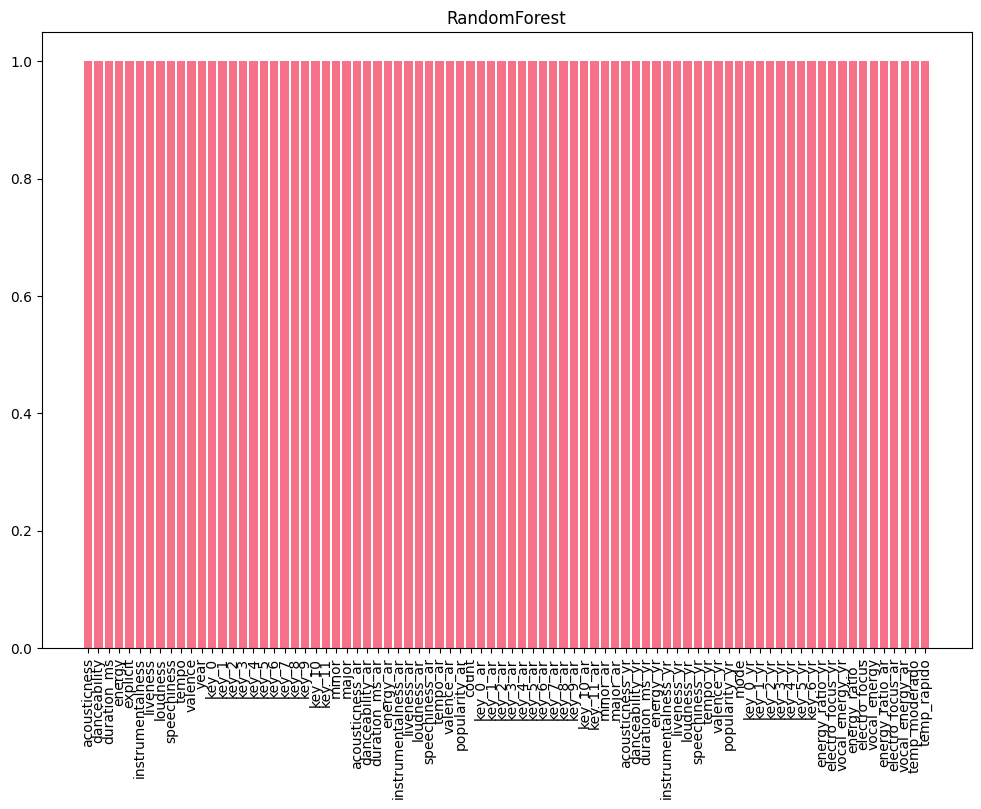

Fitting 5 folds for each of 6 candidates, totalling 30 fits

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.57      0.70      0.63     14752
           1       0.46      0.43      0.45     12415
           2       0.44      0.26      0.33      7279

    accuracy                           0.51     34446
   macro avg       0.49      0.47      0.47     34446
weighted avg       0.50      0.51      0.50     34446



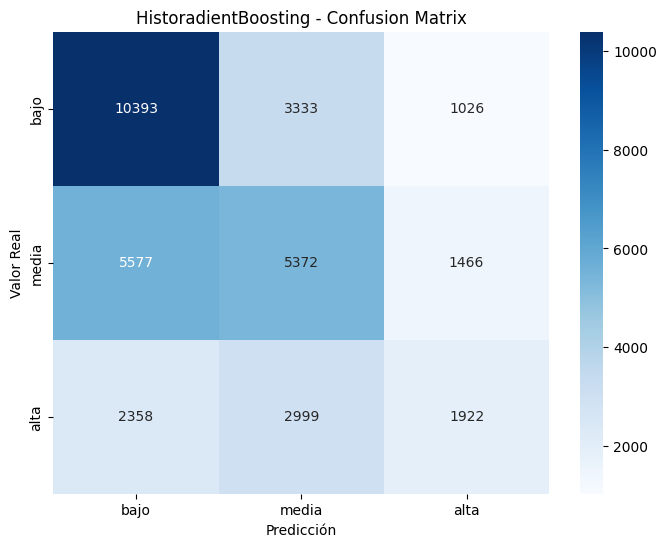

train

HistoradientBoosting
Best params: {'max_depth': 5, 'max_iter': 300}
              precision    recall  f1-score   support

           0       0.57      0.71      0.63     59010
           1       0.46      0.44      0.45     49659
           2       0.44      0.26      0.33     29115

    accuracy                           0.52    137784
   macro avg       0.49      0.47      0.47    137784
weighted avg       0.50      0.52      0.50    137784



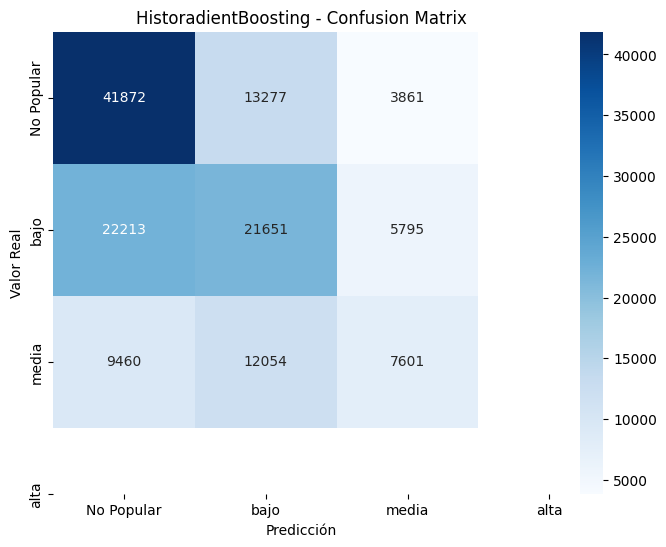

error 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'
Fitting 5 folds for each of 9 candidates, totalling 45 fits

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.57      0.70      0.63     14752
           1       0.46      0.44      0.45     12415
           2       0.43      0.27      0.33      7279

    accuracy                           0.51     34446
   macro avg       0.49      0.47      0.47     34446
weighted avg       0.50      0.51      0.50     34446



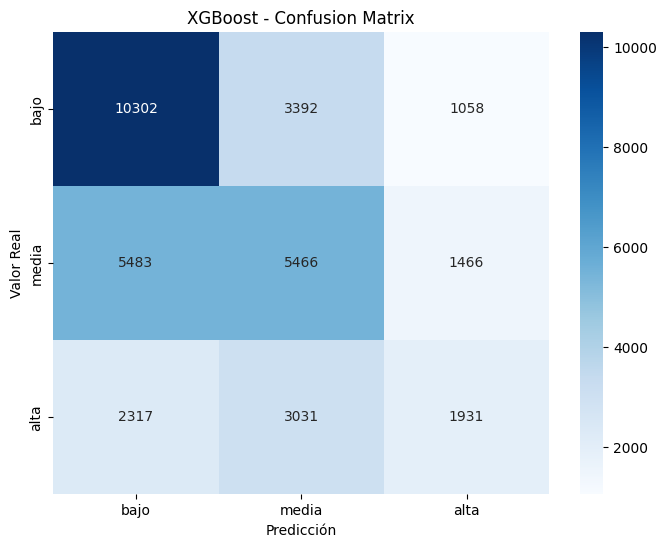

train

XGBoost
Best params: {'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.57      0.70      0.63     59010
           1       0.46      0.44      0.45     49659
           2       0.44      0.26      0.33     29115

    accuracy                           0.52    137784
   macro avg       0.49      0.47      0.47    137784
weighted avg       0.50      0.52      0.50    137784



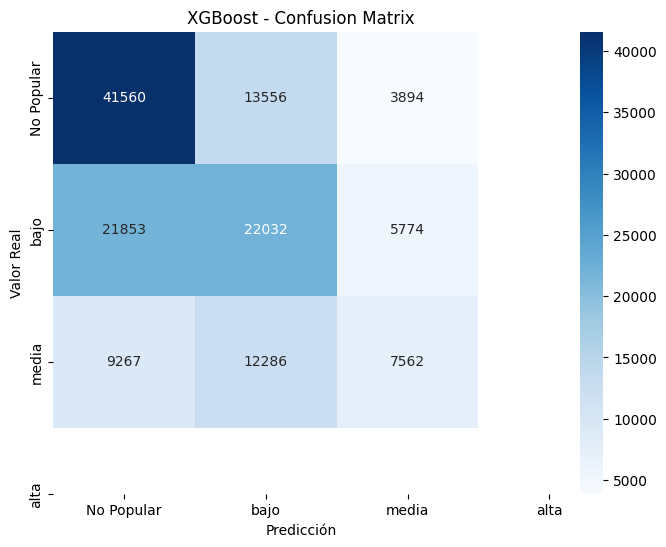

[1.]


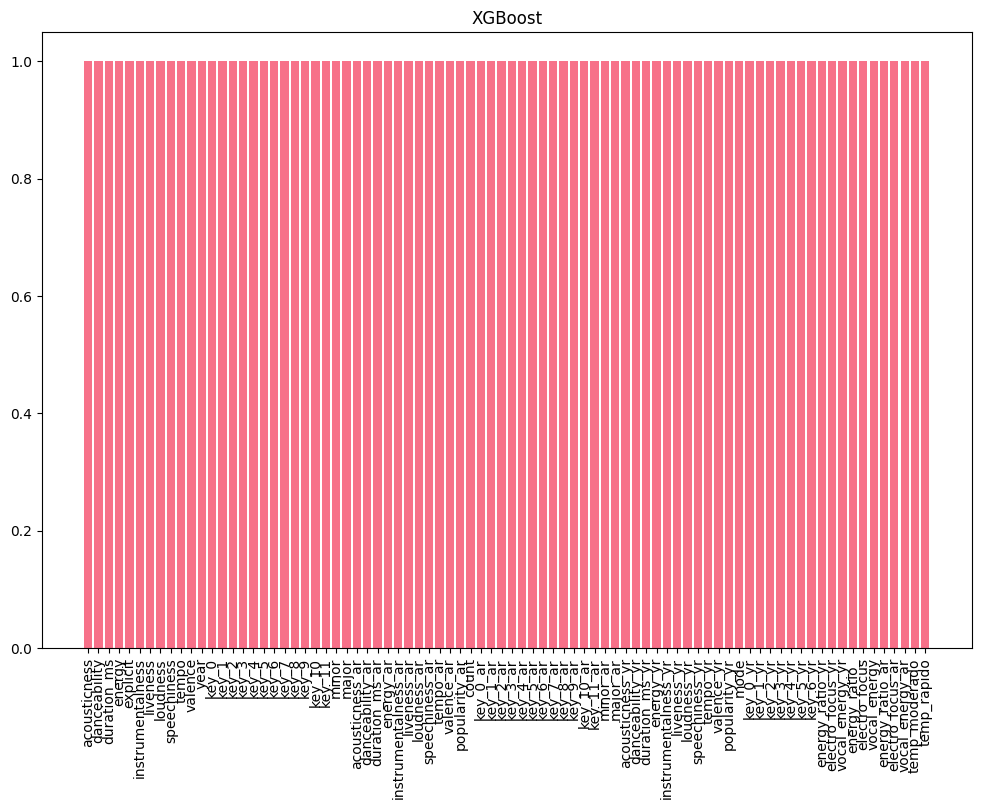

Fitting 5 folds for each of 9 candidates, totalling 45 fits

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.62      0.54      0.58     14752
           1       0.43      0.35      0.39     12415
           2       0.34      0.53      0.42      7279

    accuracy                           0.47     34446
   macro avg       0.46      0.48      0.46     34446
weighted avg       0.49      0.47      0.48     34446



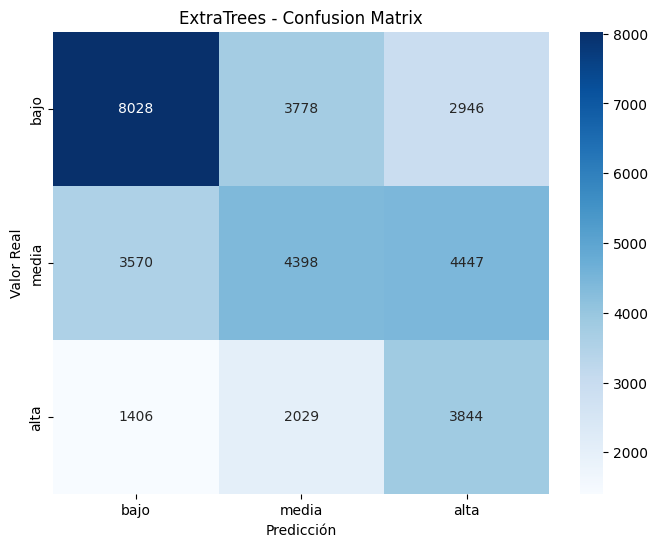

train

ExtraTrees
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.86      0.76      0.81     59010
           1       0.78      0.64      0.70     49659
           2       0.53      0.82      0.64     29115

    accuracy                           0.73    137784
   macro avg       0.72      0.74      0.72    137784
weighted avg       0.76      0.73      0.73    137784



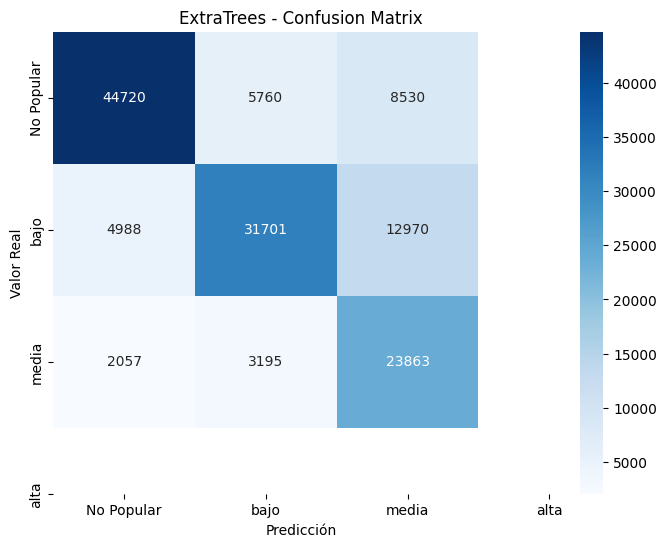

[1.]


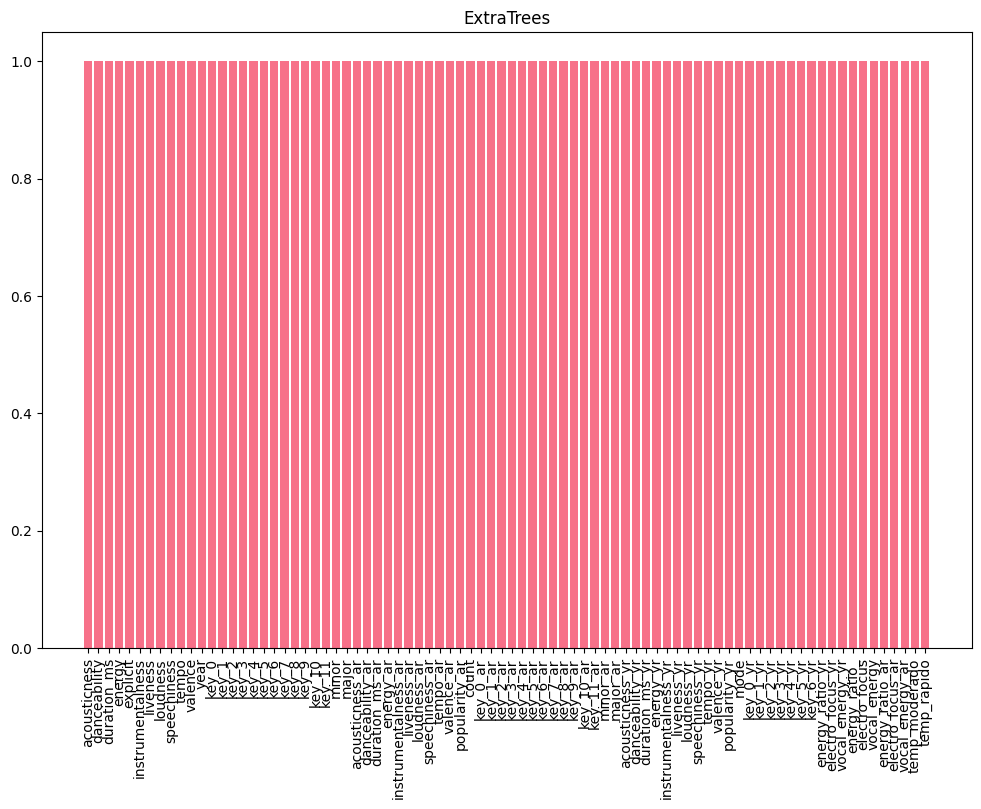

Fitting 5 folds for each of 3 candidates, totalling 15 fits

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.65      0.51      0.57     14752
           1       0.43      0.47      0.45     12415
           2       0.38      0.48      0.42      7279

    accuracy                           0.49     34446
   macro avg       0.49      0.49      0.48     34446
weighted avg       0.51      0.49      0.50     34446



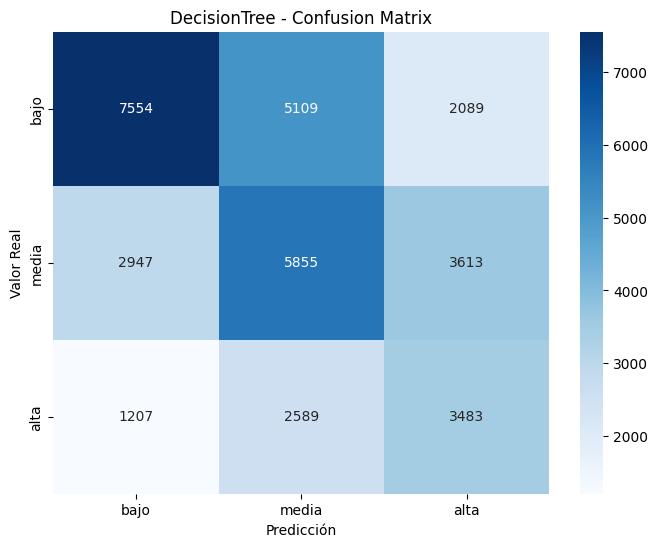

train

DecisionTree
Best params: {'max_depth': 10}
              precision    recall  f1-score   support

           0       0.66      0.52      0.58     59010
           1       0.43      0.48      0.46     49659
           2       0.39      0.49      0.43     29115

    accuracy                           0.50    137784
   macro avg       0.49      0.49      0.49    137784
weighted avg       0.52      0.50      0.50    137784



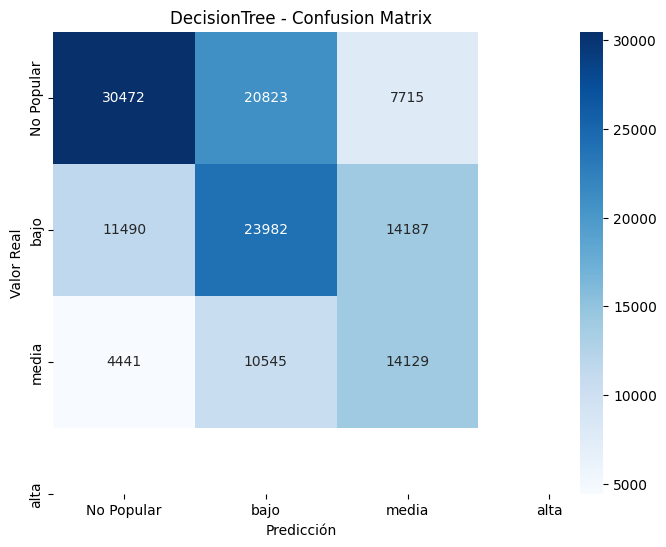

[1.]


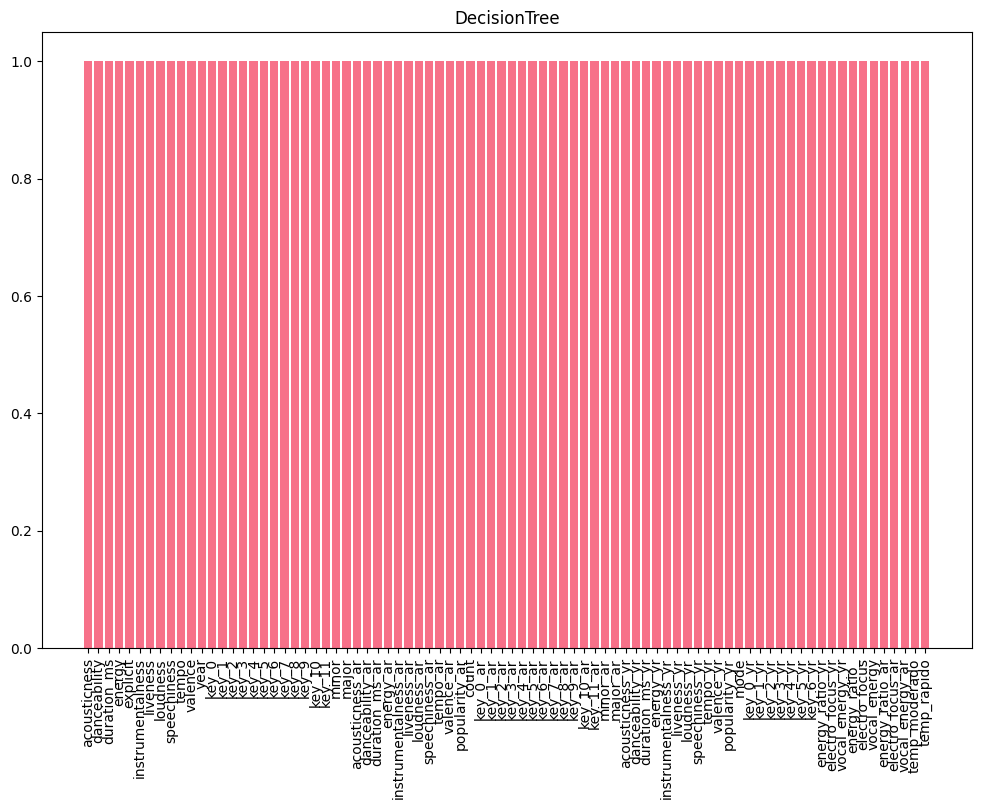

In [20]:
from sklearn.decomposition import PCA
_X=X.copy()
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
pca = PCA(n_components=0.85)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

X_train_reduce = pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'HistoradientBoosting': HistGradientBoostingClassifier(),
    'XGBoost': xgboost.XGBClassifier(objective='multi:softmax',num_class=4),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),
}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 10, 20]
    },
    'ExtraTrees': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20]
    },
    'HistoradientBoosting':{
        'max_iter':[100,200,300],
        'max_depth':[3,5],
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits

SVC
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     14752
           1       0.75      0.84      0.79     12415
           2       0.88      0.61      0.72      7279

    accuracy                           0.83     34446
   macro avg       0.84      0.80      0.81     34446
weighted avg       0.84      0.83      0.83     34446



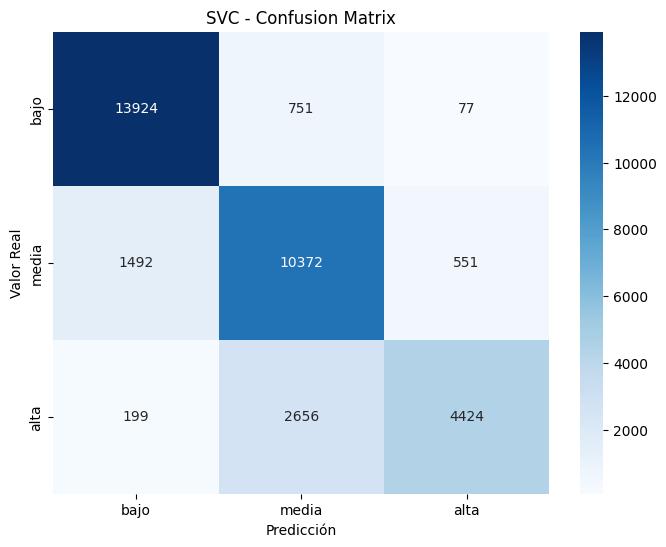

train

SVC
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     59010
           1       0.75      0.84      0.80     49659
           2       0.88      0.61      0.72     29115

    accuracy                           0.84    137784
   macro avg       0.84      0.80      0.81    137784
weighted avg       0.84      0.84      0.83    137784



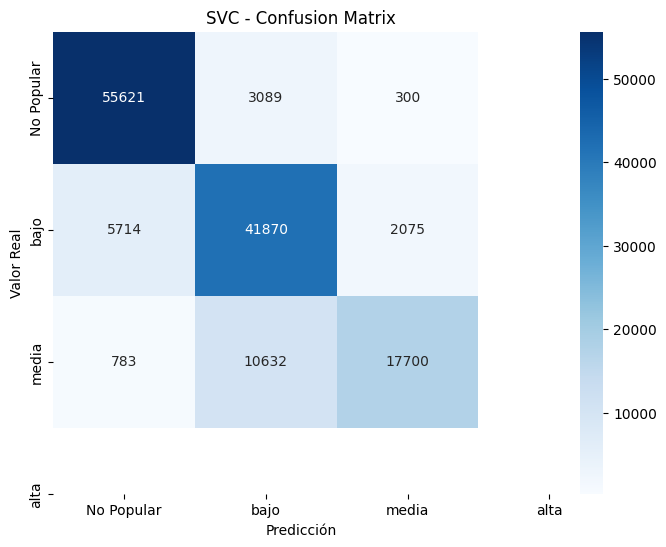

error 'SVC' object has no attribute 'feature_importances_'


In [21]:
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    "SVC":SVC(kernel='rbf')
}
param_grids = {
    'SVC':{
        "C":[1]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    print("train")
    y_pred = best.predict(X_train_reduce)
    r = classification_report(y_train_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_train_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_

# PESOS

In [22]:
selector = SelectKBest(score_func=f_classif,k=20)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
w = np.ones_like(y_train_reduce,dtype=float)
w[y_train_reduce==2]=2000
w[y_train_reduce==1]=500
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

XG = xgboost.XGBClassifier(objective='multi:softmax',num_class=3,n_estimators=500,max_depth=20)
XG.fit(X_train_reduce,y_train_reduce,sample_weight=w)



,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


              precision    recall  f1-score   support

           0       0.94      0.90      0.92     14752
           1       0.75      0.84      0.79     12415
           2       0.79      0.70      0.74      7279

    accuracy                           0.83     34446
   macro avg       0.83      0.81      0.82     34446
weighted avg       0.84      0.83      0.84     34446



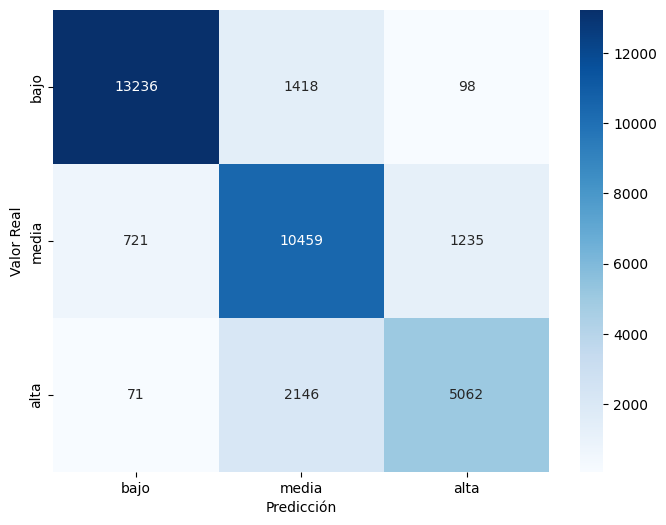

train

SVC
Best params: {'C': 1}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59010
           1       1.00      0.99      0.99     49659
           2       0.99      1.00      0.99     29115

    accuracy                           1.00    137784
   macro avg       0.99      1.00      1.00    137784
weighted avg       1.00      1.00      1.00    137784



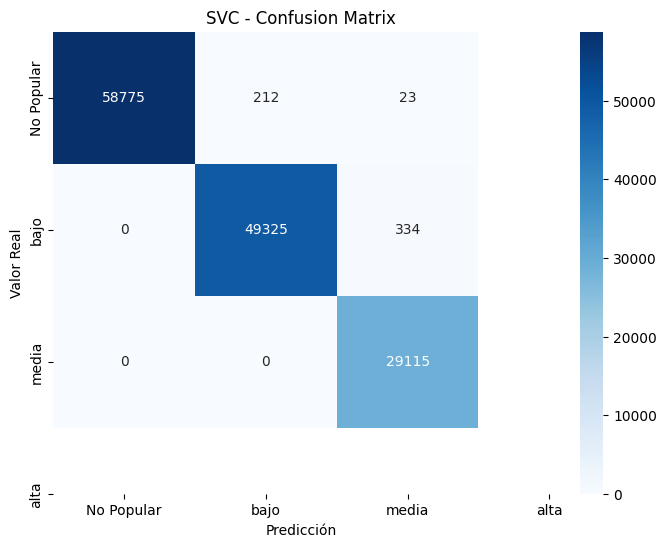

In [24]:
y_pred = XG.predict(X_test_scaled)

r = classification_report(y_test_reduce, y_pred)
print(r)
cm = confusion_matrix(y_test_reduce, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()
print("train")
y_pred = XG.predict(X_train_reduce)
r = classification_report(y_train_reduce, y_pred)
print(f"\n{name}")
print(f"Best params: {grid.best_params_}")
print(r)
cm = confusion_matrix(y_train_reduce, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
plt.title(f'{name} - Confusion Matrix')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

In [ ]:
y_pred = XG.predict(X_train_reduce)

r = classification_report(y_train_reduce, y_pred)
print(r)
cm = confusion_matrix(y_train_reduce, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()
print("train")
y_pred = best.predict(X_train_reduce)
r = classification_report(y_train_reduce, y_pred)
print(f"\n{name}")
print(f"Best params: {grid.best_params_}")
print(r)
cm = confusion_matrix(y_train_reduce, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
plt.title(f'{name} - Confusion Matrix')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()